# Profiling Allantois upon Eomes KD

In [1]:
here::i_am("rna_atac/differential/v2/03_allantois.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ArchR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
here::i_am("rna_atac/differential/v2/03_allantois.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))
suppressPackageStartupMessages(library(ArchR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [3]:
# Define custom functions
plot_region = function(input_gene){
    tmp1 = DEG_DAR[celltype %in% args$celltypes & gene %in% input_gene] %>% 
        .[order(-abs(ATAC_logFC))] %>% unique(by = 'peak')
    gene_region = ArchRProject@geneAnnotation$genes[grep(paste0('^', input_gene, '$'), ArchRProject@geneAnnotation$genes$symbol)]
    peak_regions = as.numeric(str_split(str_split(tmp1$peak, ':') %>% map_chr(2), '-') %>% map_chr(1))
    start = min(c(start(ranges(gene_region)), peak_regions))
    end = max(c(c(end(ranges(gene_region)), peak_regions + 600)))
    input_region = paste0(gene_region@seqnames@values, ':', start, '-', end)

    mypal <- colorRampPalette(c("#fff7b8","grey98","#d0ffc2"))(100)
    x <- tmp1[, ATAC_logFC]
    highlight_colors = map2color(x,mypal, limits = c(-max(abs(c(0,x))), max(abs(c(0,x)))))
    names(highlight_colors) = str_split(str_split(tmp1[, peak], ':') %>% map_chr(2), '-') %>% map_chr(1)

    plot_browser_track(gene = input_gene, # Only choose one of gene/input_region, otherwise will use region
                                  input_region = input_region, 
                                  bigwigs = WT_plot, 
                                  extend.upstream = 3e3,
                                  extend.downstream = 3e3, 
                                  highlight_regions = if(length(tmp1$peak)>0){tmp1$peak}else{NULL},
                                  downsample.rate = 1, 
                                  no_label = F, 
                                  plot_expression = T,
                                  background_color = 'white',
                                  highlight_color = if(length(highlight_colors)>0){highlight_colors}else{NULL},
                                  bw_height = 1.5, 
                                  gene_height = 2.5,
                                  bw_width = 40)
}

In [40]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# Load Differential analysis
args$expression = file.path(io$basedir, 'results/rna_atac/differential/v2/expression/')
args$accessibility = file.path(io$basedir, 'results/rna_atac/differential/v2/Accessibility/')
args$WT_trajectory = file.path(io$basedir, 'results/rna_atac/trajectory/v3')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/differential/v2/03_allantois/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

# Celltypes to use
args$celltypes = c('Allantois_Precursor', 'Allantois')

# multiome atlas endothelium 
args$atlas_sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/rna/SingleCellExperiment.rds'
args$atlas_meta = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/mapping/sample_metadata_after_mapping.txt.gz'

In [5]:
# Load browser track files
ArchRProject = suppressMessages(ArchR::loadArchRProject(io$archR.directory))
args$atlas_bws = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR/GroupBigWigs/celltype_genotype/'
args$vitro_bws = file.path(io$basedir, 'processed/atac/archR/GroupBigWigs/celltypeV2_genotype/')

bigwigs.data_vitro = data.table(celltype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(1),
                    genotype = list.files(args$vitro_bws, 'bw') %>% str_split(., '\\.') %>% map_chr(2) %>% str_split('-') %>% map_chr(1),
                    path =  paste0(args$vitro_bws, list.files(args$vitro_bws, 'bw'))) %>% 
                .[,name := gsub('KO', 'KD', paste0(celltype, '-', genotype))] %>% 
                .[,color := ifelse(genotype == 'KO', '#FF0000', '#000000')] %>% 
                .[name != 'Blood_Progenitor-KO']

atlas_files = list.files(args$atlas_bws, 'WT-TileSize-100-normMethod-ReadsInTSS-ArchR.bw')
bigwigs.data_vivo = data.table(celltype = gsub('.WT', '', atlas_files %>% str_split(., '-') %>% map_chr(1)),
                    genotype = 'Atlas',
                    path =  paste0(args$atlas_bws, atlas_files)) %>% 
                .[,name := paste0(celltype, ' (Atlas)')] %>% 
                .[,color := opts$celltype.colors[celltype]]

bigwigs.data = rbind(bigwigs.data_vitro, bigwigs.data_vivo)

In [6]:

bigwig_order = c('Allantois (Atlas)',
                 'Allantois-WT',
                 'Allantois-KD',
                 'Allantois_Precursor-WT',
                 'Allantois_Precursor-KD'
                )

WT_plot = bigwigs.data %>% copy() %>%
    .[match(bigwig_order, name)] %>% 
    .[, name := factor(name, levels = bigwig_order)]

In [7]:
# Load meta
meta = fread(args$metadata)[day!='D3']

#### Load Data

In [8]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [9]:
# Load differential RNA
DEGs = fread(sprintf('%s/DEGs_edgeR_pb.txt.gz', args$expression))[celltype %in% args$celltypes] %>% 
        .[,sig:=ifelse(abs(logFC)>0.5 & padj_fdr < 0.05, TRUE, FALSE)] %>% 
        .[sig == T] %>% .[, sig := NULL]
DEGs = DEGs[!gene %in% c('Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bh1')]

# Load differential ATAC
DARs = fread(sprintf('%s/DARs_edgeR_pb.txt.gz', args$accessibility))[celltype %in% args$celltypes] %>% 
        .[,sig:=ifelse(abs(logFC)>0.5 & padj_fdr < 0.05, TRUE, FALSE)] %>% 
        .[sig == T] %>% .[, sig := NULL]

# Load peak2gene linkage
peak_gene_correlation = fread(file.path(args$WT_trajectory, 'acc_gene_correlation.txt.gz')) %>% 
    # .[padj<0.05] %>% 
    .[]

# Get differential genes from trajectory analysis between the two lineages in WT
patternGenes = fread(file.path(args$WT_trajectory, 'patternGenes.txt.gz'))
endGenes = fread(file.path(args$WT_trajectory, 'endGenes.txt.gz'))
genes_keep = unique(rbind(patternGenes[,c('gene', 'waldStat', 'padj', 'sig')], endGenes[,c('gene', 'waldStat', 'padj', 'sig')])[sig==TRUE][order(padj, -waldStat)]$gene)

# RNA

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


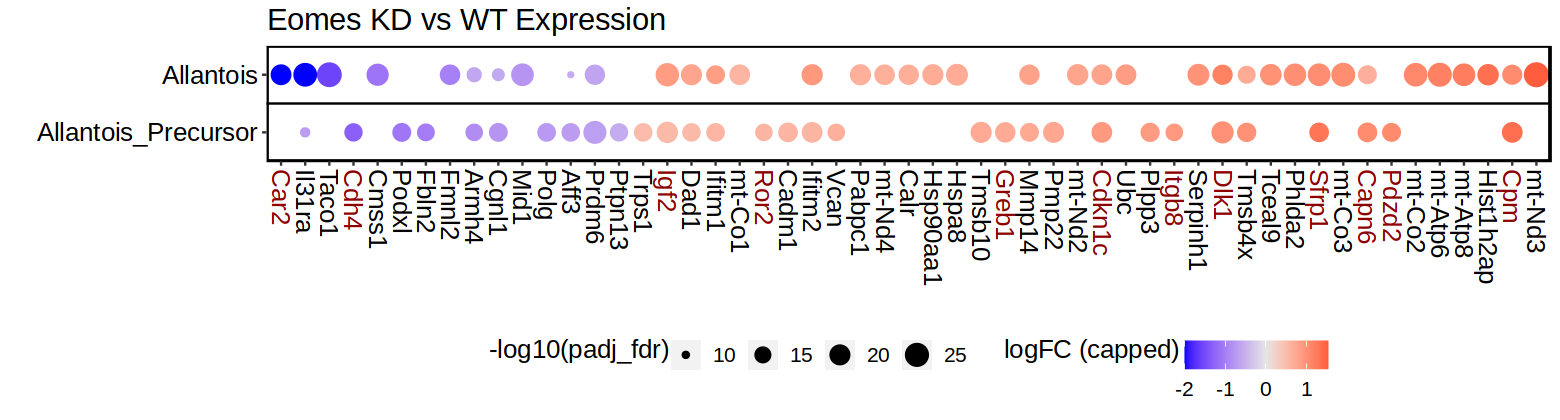

In [14]:
features = DEGs[celltype %in% args$celltypes, ] %>% 
    #.[order(-abs(logFC)),] %>% 
    .[order(padj_fdr)] %>%
     .[,head(.SD, 30), by=celltype] %>% 
    .[order(logFC)] %>% 
    .$gene %>% unique()

# # Turn dt in matrix
# DEGs.mtx = DEGs[gene %in% features & celltype %in% celltypes, c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
# DEGs.mtx[is.na(DEGs.mtx)] = 0
# DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# # Cluster genes by logFC
# order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
to.plot = DEGs[celltype %in% args$celltypes & gene %in% features & padj_fdr < 0.05] %>%
     # .[abs(logFC) > args$logFC_thr] %>% 
    .[, gene := factor(gene, levels = features)] %>%
    .[, celltype := factor(celltype, levels = args$celltypes)] %>% 
    .[, logFC_capped := ifelse(logFC >= 2, 2, 
                               ifelse(logFC <= -2, -2, logFC))]

options(repr.plot.width=13, repr.plot.height=3.5)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC_capped)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC (capped)') + 
    xlab('') + ylab('') +
    geom_hline(yintercept=seq(.5, 20, 1), alpha=0.2) + 
    geom_hline(yintercept=c(1.5, 2.5), alpha=1) + 
    scale_y_discrete(limits = args$celltypes, expand = c(0, 0.5)) + 
    ggtitle('Eomes KD vs WT Expression') + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5, color = ifelse(unique(to.plot[order(gene)]$gene) %in% genes_keep, 'darkred', 'black')),
         axis.text=element_text(size=15, color='black'),
         text=element_text(size=15),
            panel.border = element_rect(color='black', linewidth=1, fill = NA),
            panel.background = element_blank(),
            axis.line = element_blank(),
          legend.position = 'bottom',
          legend.title = element_text(vjust=1)
)

'select()' returned 1:many mapping between keys and columns



GOALL,Term,Ont,N,DE,P.DE,FDR,enrichment,genes
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GO:0042773,ATP synthesis coupled electron transport,BP,70,19,3.950074e-16,9.930312e-14,100,"Uqcc3, Dld, Chchd2, mt-Co1, mt-Co2, mt-Co3, mt-Cytb, mt-Nd1, mt-Nd2, mt-Nd3, mt-Nd4, Ndufv1, Ndufs2, Uqcrfs1, Uqcrc2, Uqcrb, Sdhb, Ndufa8, Ndufs7"
GO:0019646,aerobic electron transport chain,BP,57,17,1.132170e-15,2.697984e-13,100,"Uqcc3, Dld, mt-Co1, mt-Co3, mt-Cytb, mt-Nd1, mt-Nd2, mt-Nd3, mt-Nd4, Ndufv1, Ndufs2, Uqcrfs1, Uqcrc2, Uqcrb, Sdhb, Ndufa8, Ndufs7"
GO:0042775,mitochondrial ATP synthesis coupled electron transport,BP,68,18,3.933301e-15,8.409545e-13,100,"Uqcc3, Dld, Chchd2, mt-Co1, mt-Co3, mt-Cytb, mt-Nd1, mt-Nd2, mt-Nd3, mt-Nd4, Ndufv1, Ndufs2, Uqcrfs1, Uqcrc2, Uqcrb, Sdhb, Ndufa8, Ndufs7"
GO:0042776,proton motive force-driven mitochondrial ATP synthesis,BP,52,17,1.299961e-14,2.478267e-12,100,"Ndufb11, mt-Atp6, mt-Atp8, mt-Nd1, mt-Nd2, mt-Nd3, mt-Nd4, Ndufv1, Ndufs2, Ndufs5, Ndufb5, Ndufa9, Ndufb7, Sdhb, Ndufa8, Ndufab1, Ndufs7"
GO:0015986,proton motive force-driven ATP synthesis,BP,52,17,4.983778e-14,8.778427e-12,100,"Ndufb11, mt-Atp6, mt-Atp8, mt-Nd1, mt-Nd2, mt-Nd3, mt-Nd4, Ndufv1, Ndufs2, Ndufs5, Ndufb5, Ndufa9, Ndufb7, Sdhb, Ndufa8, Ndufab1, Ndufs7"
GO:0010257,NADH dehydrogenase complex assembly,BP,55,15,5.664294e-13,8.414420e-11,100,"Ndufb11, mt-Nd1, mt-Nd2, mt-Nd4, Ndufs2, Ndufs5, Ndufb5, Ndufa9, Tmem126a, Ndufb7, Dmac1, Timm21, Ndufa8, Ndufab1, Ndufs7"
GO:0032981,mitochondrial respiratory chain complex I assembly,BP,55,15,5.664294e-13,8.414420e-11,100,"Ndufb11, mt-Nd1, mt-Nd2, mt-Nd4, Ndufs2, Ndufs5, Ndufb5, Ndufa9, Tmem126a, Ndufb7, Dmac1, Timm21, Ndufa8, Ndufab1, Ndufs7"
GO:0006120,"mitochondrial electron transport, NADH to ubiquinone",BP,29,9,4.369301e-09,3.982331e-07,100,"Dld, mt-Nd1, mt-Nd2, mt-Nd3, mt-Nd4, Ndufv1, Ndufs2, Ndufa8, Ndufs7"
GO:2000679,positive regulation of transcription regulatory region DNA binding,BP,24,8,2.460422e-08,1.851548e-06,100,"Parp1, Ctnnb1, Gata3, Hand2, Twist1, Gtf2b, Lamtor5, Ddrgk1"


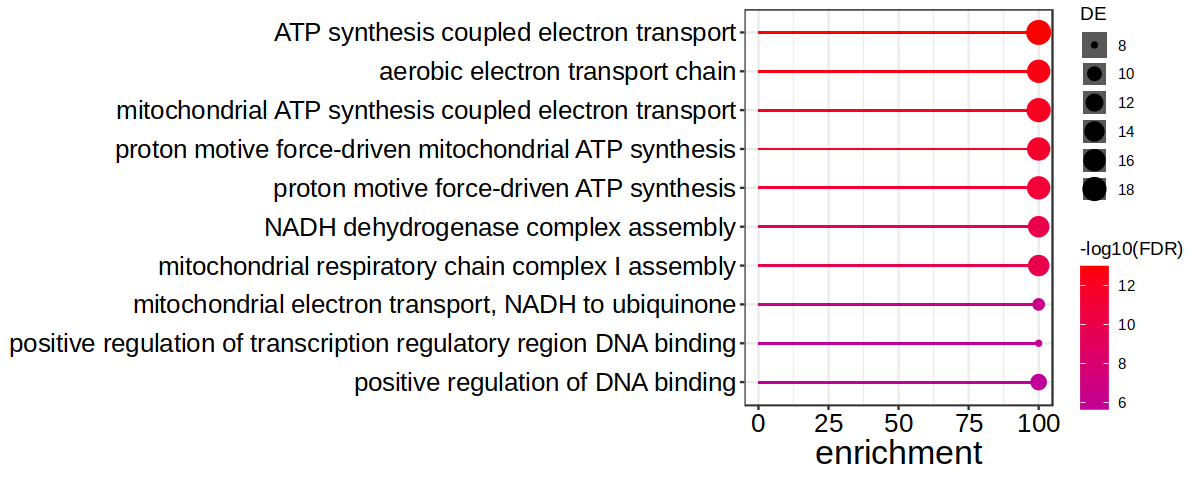

In [15]:
genes = DEGs[logFC>0, gene]
tmp = do_GO(genes, background = rownames(rna.sce))
head(tmp[[1]] %>% .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 20 & N < 1000 & DE > 3 & enrichment > 3] %>% .[order(-enrichment)], 10)
tmp[[2]]

'select()' returned 1:many mapping between keys and columns



GOALL,Term,Ont,N,DE,P.DE,FDR,enrichment,genes
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GO:0045879,negative regulation of smoothened signaling pathway,BP,39,5,6.673854e-05,0.004412652,100.00000,"Gli2, Ptch1, Tulp3, Mosmo, Sufu"
GO:0032232,negative regulation of actin filament bundle assembly,BP,39,5,7.558836e-05,0.004926595,100.00000,"Arhgap6, Wasf2, Arhgap28, Shank3, Cgnl1"
GO:0060045,positive regulation of cardiac muscle cell proliferation,BP,29,4,2.766614e-04,0.014483258,100.00000,"Gata4, Ncam1, Nrg1, Tgfbr3"
GO:0086010,membrane depolarization during action potential,BP,31,4,3.602165e-04,0.017739218,100.00000,"Ank3, Cacna1c, Cacna1d, Cacnb2"
GO:0048566,embryonic digestive tract development,BP,33,4,4.604114e-04,0.021235547,100.00000,"Gata4, Gli2, Foxf1, Pcsk5"
GO:0021904,dorsal/ventral neural tube patterning,BP,33,4,4.604114e-04,0.021235547,100.00000,"Gli2, Ptch1, Tulp3, Sufu"
GO:0051497,negative regulation of stress fiber assembly,BP,33,4,5.173007e-04,0.023434234,100.00000,"Arhgap6, Wasf2, Arhgap28, Cgnl1"
GO:1902003,regulation of amyloid-beta formation,BP,36,4,7.178208e-04,0.030637286,99.64506,"Apoe, Epha4, Spon1, Gga3"
GO:0035640,exploration behavior,BP,37,4,7.178208e-04,0.030637286,94.33163,"Apoe, Dlg4, Prkce, Shank3"


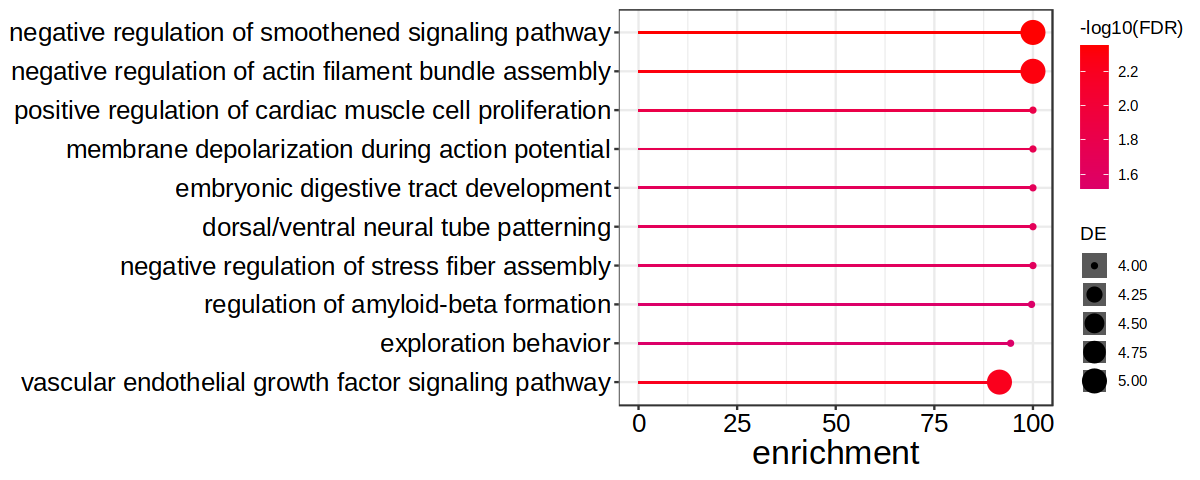

In [16]:
genes = DEGs[logFC<0, gene]
tmp = do_GO(genes, background = rownames(rna.sce))
head(tmp[[1]] %>% .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 20 & N < 1000 & DE > 3 & enrichment > 3] %>% .[order(-enrichment)], 10)
tmp[[2]]

In [41]:
args$homer = sprintf('%s/promoters/', args$outdir)
dir.create(args$homer, recursive=TRUE, showWarnings =FALSE)

tmp = as.data.table(ArchRProject@geneAnnotation$genes) %>% 
    .[, TSS := ifelse(strand == '+', start, end)] %>% 
    .[, `:=`(promoter_start = TSS - 0,
             promoter_end = TSS + 1)]
bed = tmp[,c('seqnames', 'promoter_start', 'promoter_end')] %>% setnames(c('chr', 'start', 'end'))
fwrite(bed, sprintf('%s/background.bed', args$homer) , col.names=F, sep='\t')

In [42]:
# Up
features_up = DEGs[celltype %in% args$celltypes  & padj_fdr < 0.05 & logFC > 0.5, ] %>%
    .[order(-logFC)]

tmp = as.data.table(ArchRProject@geneAnnotation$genes) %>% 
    .[symbol %in% features_up$gene] %>%
    .[, TSS := ifelse(strand == '+', start, end)] %>% 
    .[, `:=`(promoter_start = TSS,
             promoter_end = TSS+1)]
bed = tmp[,c('seqnames', 'promoter_start', 'promoter_end')] %>% setnames(c('chr', 'start', 'end'))

fwrite(bed, sprintf('%s/up.bed', args$homer) , col.names=F, sep='\t')

# Down
features_down = DEGs[celltype %in% args$celltypes  & padj_fdr < 0.05 & logFC <= -0.5, ] %>%
    .[order(-logFC)]

tmp = as.data.table(ArchRProject@geneAnnotation$genes) %>% 
    .[symbol %in% features_down$gene] %>%
    .[, TSS := ifelse(strand == '+', start, end)] %>% 
    .[, `:=`(promoter_start = TSS - 0,
             promoter_end = TSS + 1)]
bed = tmp[,c('seqnames', 'promoter_start', 'promoter_end')] %>% setnames(c('chr', 'start', 'end'))

fwrite(bed, sprintf('%s/down.bed', args$homer) , col.names=F, sep='\t')

# Motif search using Homer
files = gsub('.bed', '', list.files(args$homer, pattern = '.bed'))
mclapply(files[2:3], function(x){
    cmd = sprintf('/rds/project/rds-SDzz0CATGms/users/bt392/software/homer/bin/findMotifsGenome.pl %s/%s.bed mm10 %s/%s -size 75 -bg %s/background.bed -S 5 -len 8,10,12  -p 24', 
                       args$homer, x,
                         args$homer, x,
                          args$homer)
    system(cmd)
},mc.cores=12)

[[1]]
[1] 0

[[2]]
[1] 0

### RNA & ATAC

In [17]:
# Add multiome atlas expression to rna object for plotting
atlas_meta = fread(args$atlas_meta)[celltype %in% args$celltypes]
atlas = readRDS(args$atlas_sce)[, atlas_meta$cell]

atlas = logNormCounts(atlas)

atlas$genotype = 'Atlas'
atlas$celltype_v2 = atlas_meta$celltype

genes = intersect(rownames(atlas), rownames(rna.sce))

colData(rna.sce) = colData(rna.sce)[,c('genotype', 'celltype_v2')]
colData(atlas) = colData(atlas)[,c('genotype', 'celltype_v2')]

rna.sce = cbind(rna.sce[genes,], atlas[genes,])

In [18]:
# link DEGs & DARs
DEG_DAR = DEGs %>% copy() %>%  
                    .[!is.na(logFC)] %>% 
                   setnames(colnames(.)[2:7], paste0('RNA_', colnames(.)[2:7])) %>% 
          merge(., peak_gene_correlation[,c('peak', 'gene', 'cor', 'padj')], 
                by = 'gene') %>% 
          merge(., DARs %>% copy() %>%  
                    .[!is.na(logFC)] %>% 
                   setnames(colnames(.)[2:7], paste0('ATAC_', colnames(.)[2:7])),
                by = c('celltype', 'peak'))
head(DEG_DAR)

celltype,peak,gene,RNA_logFC,RNA_padj_fdr,RNA_mean_groupA,RNA_mean_groupB,RNA_cdr_groupA,RNA_cdr_groupB,cor,padj,ATAC_logFC,ATAC_padj_fdr,ATAC_mean_groupA,ATAC_mean_groupB,ATAC_cdr_groupA,ATAC_cdr_groupB
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Allantois,chr10:110782574-110783174,Csrp2,0.510,2.66e-15,8.05,8.48,0.92,0.97,0.669,0.0098953868,0.623,8.31e-05,2.36,2.89,0.08,0.16
Allantois,chr10:111024500-111025100,Csrp2,0.510,2.66e-15,8.05,8.48,0.92,0.97,0.702,0.0053599614,0.769,5.00e-08,2.59,3.31,0.09,0.20
Allantois,chr10:117569305-117569905,Cpm,1.060,2.09e-19,6.67,7.65,0.52,0.80,0.291,0.4008394364,0.855,1.37e-07,2.20,2.94,0.08,0.18
Allantois,chr10:119676158-119676758,Grip1,-0.692,1.66e-15,7.98,7.23,0.68,0.57,-0.433,0.1613547310,0.964,4.21e-12,2.54,3.38,0.07,0.22
Allantois,chr10:119691504-119692104,Grip1,-0.692,1.66e-15,7.98,7.23,0.68,0.57,0.784,0.0007824271,0.669,1.13e-05,2.46,3.06,0.08,0.20
Allantois,chr10:119692225-119692825,Grip1,-0.692,1.66e-15,7.98,7.23,0.68,0.57,0.511,0.0798817722,0.910,4.58e-08,2.11,2.86,0.07,0.18


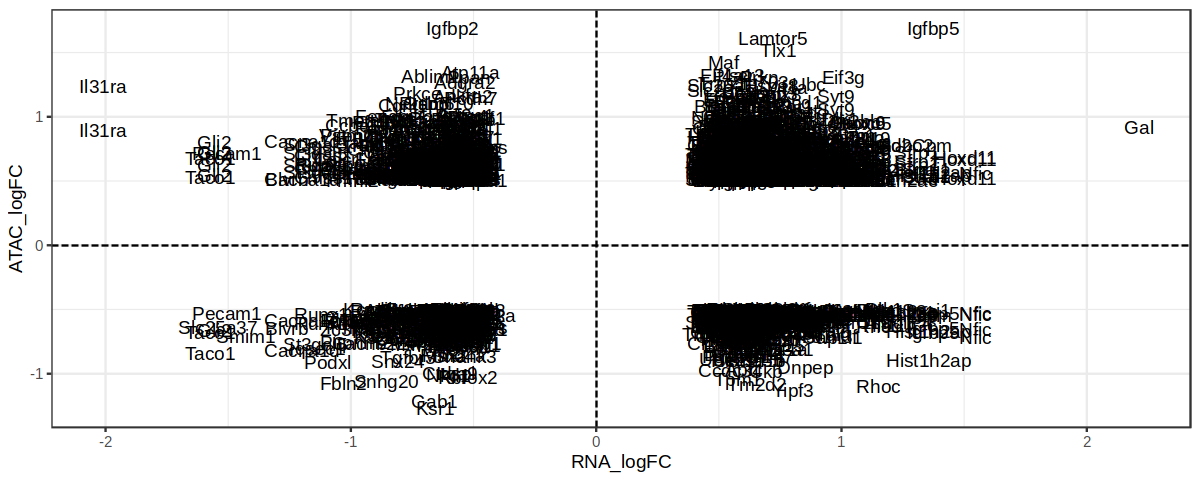

In [19]:
ggplot(DEG_DAR[celltype %in% args$celltypes], aes(RNA_logFC, ATAC_logFC)) + 
    geom_text(aes(label = gene)) + 
    geom_hline(yintercept = 0, linetype = 'longdash') + 
    geom_vline(xintercept = 0, linetype = 'longdash') + 
    theme_bw()

In [20]:
unique(rna.sce$genotype)

[1] "WT"    "KO"    "Atlas"

In [21]:
test = peak_gene_correlation[,c('peak', 'gene', 'cor', 'padj', 'distance')] %>% 
          merge(., DARs %>% copy() %>%  
                    .[!is.na(logFC)] %>% 
                   setnames(colnames(.)[2:7], paste0('ATAC_', colnames(.)[2:7])),
                by = c('peak')) %>% 
        .[gene %in% genes_keep]

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation ideoms with `aes()`”


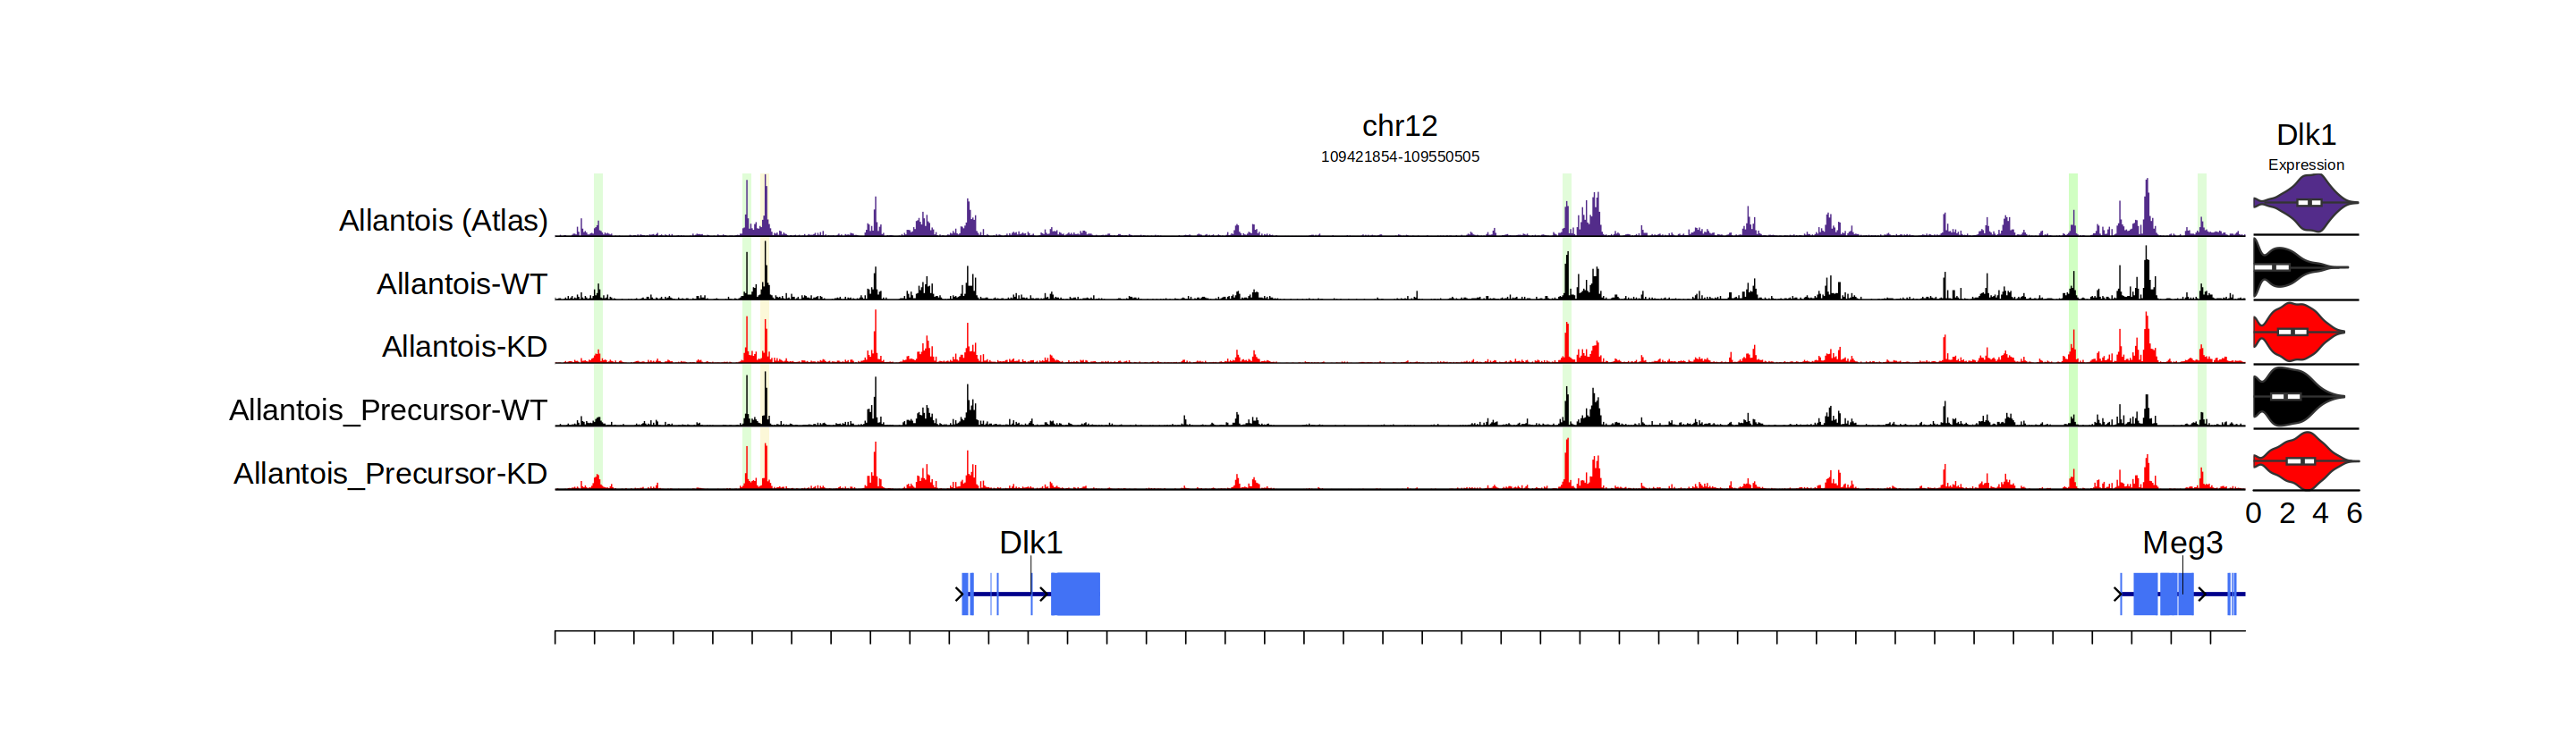

In [22]:
options(repr.plot.width=21, repr.plot.height=5.5)
plot_region('Dlk1')

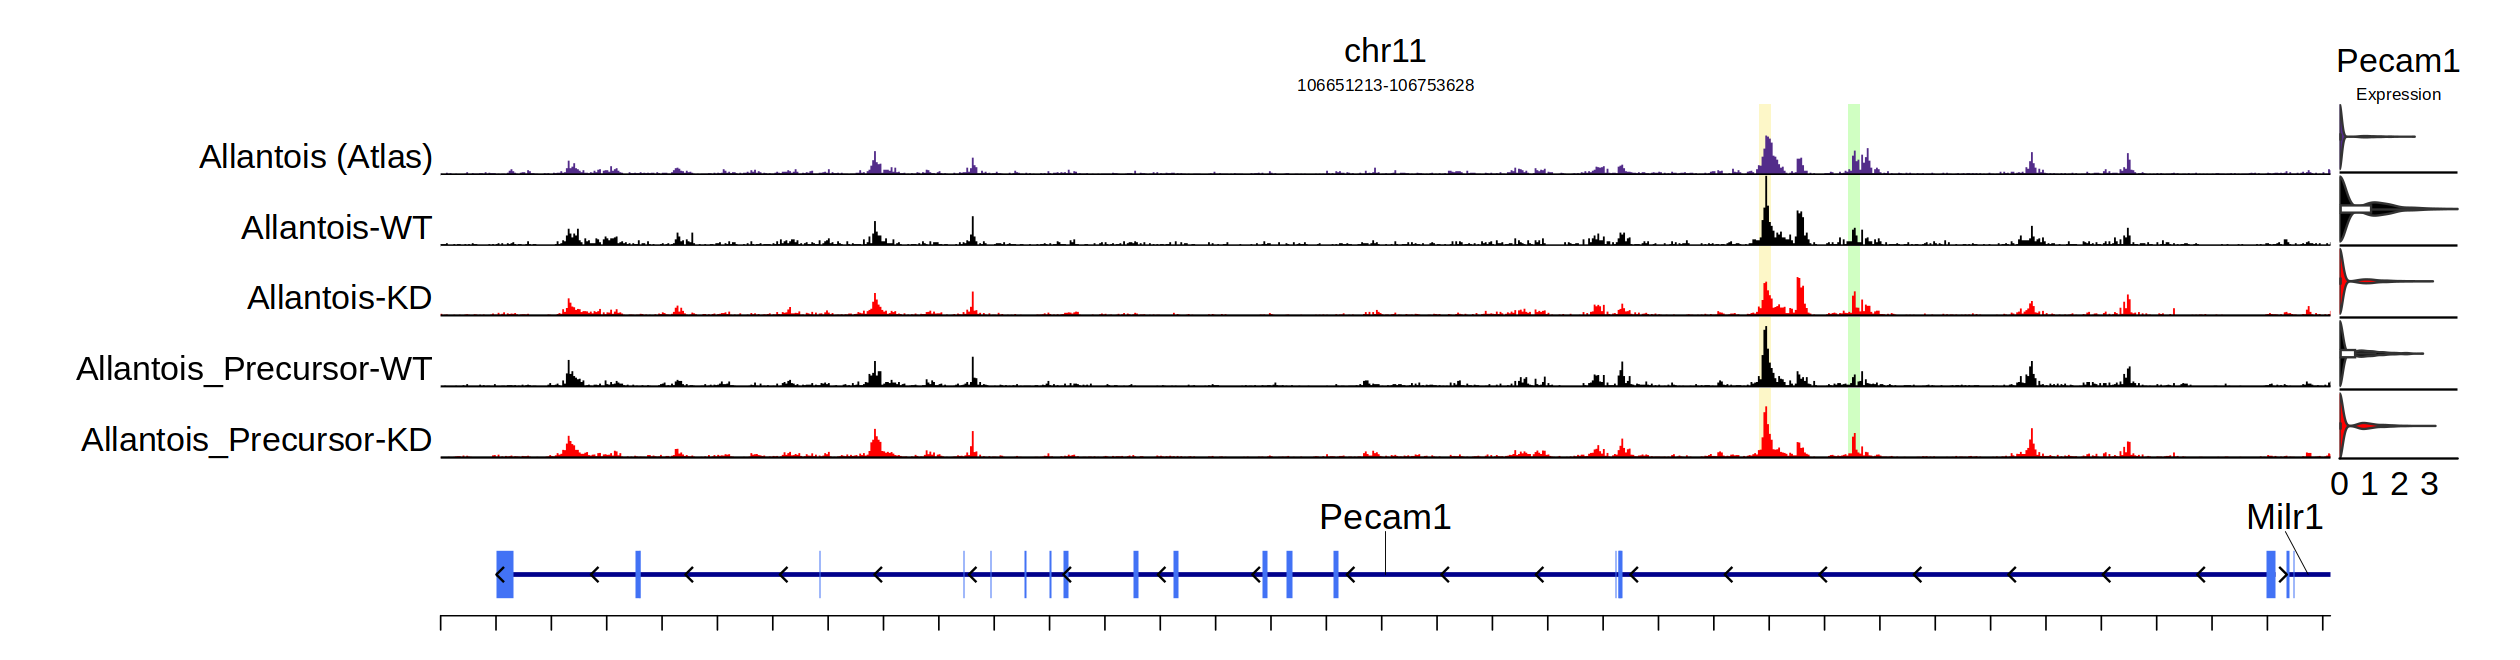

In [45]:
options(repr.plot.width=21, repr.plot.height=5.5)
plot_region('Pecam1')

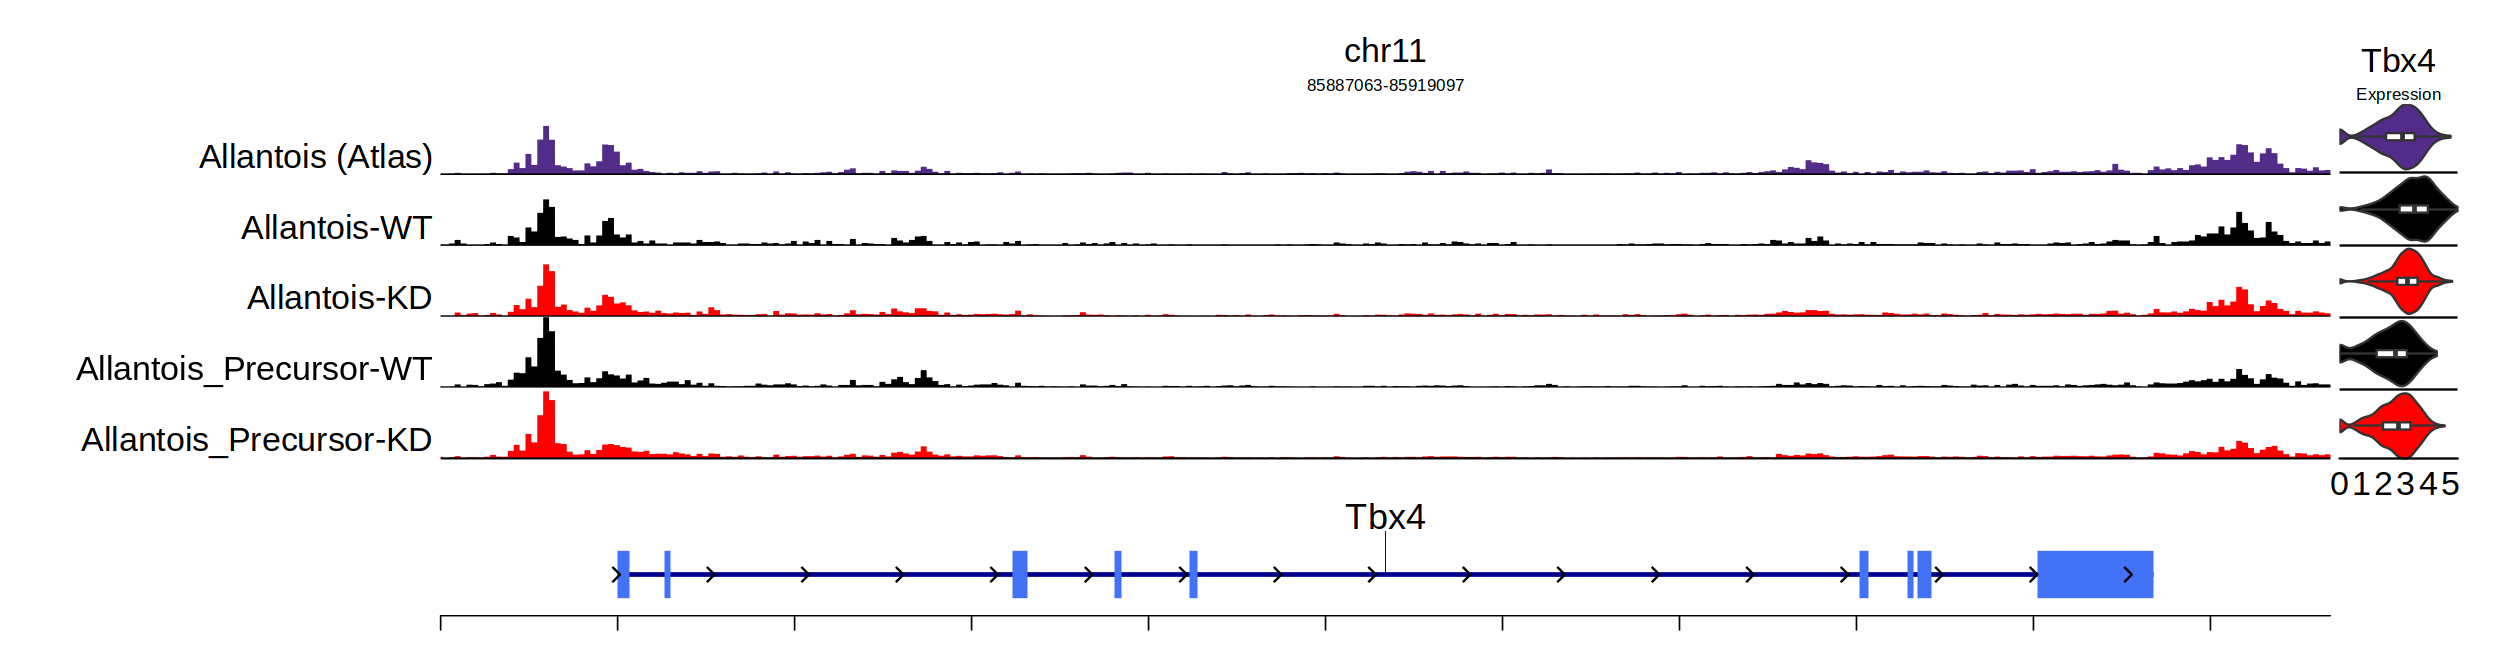

In [47]:
plot_region('Tbx4')

In [50]:
head(DEG_DAR[celltype %in% args$celltypes][order(RNA_logFC)])

celltype,peak,gene,RNA_logFC,RNA_padj_fdr,RNA_mean_groupA,RNA_mean_groupB,RNA_cdr_groupA,RNA_cdr_groupB,cor,padj,ATAC_logFC,ATAC_padj_fdr,ATAC_mean_groupA,ATAC_mean_groupB,ATAC_cdr_groupA,ATAC_cdr_groupB
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Allantois,chr13:112410750-112411350,Il31ra,-2.010,4.89e-25,7.63,5.58,0.76,0.43,0.370,0.2543720,0.892,2.38e-08,2.26,3.01,0.06,0.18
Allantois,chr13:112491655-112492255,Il31ra,-2.010,4.89e-25,7.63,5.58,0.76,0.43,0.347,0.2933980,1.237,2.10e-12,1.92,2.98,0.05,0.16
Allantois,chr11:106026629-106027229,Taco1,-1.574,5.88e-27,10.20,8.56,0.99,0.89,-0.069,0.8778090,0.528,1.59e-03,2.27,2.71,0.07,0.15
Allantois,chr11:106066489-106067089,Taco1,-1.574,5.88e-27,10.20,8.56,0.99,0.89,-0.095,0.8254431,0.678,1.52e-10,3.26,3.89,0.15,0.34
Allantois,chr11:106134474-106135074,Taco1,-1.574,5.88e-27,10.20,8.56,0.99,0.89,-0.017,0.9719876,-0.839,1.11e-10,3.33,2.60,0.15,0.16
Allantois,chr11:106135086-106135686,Taco1,-1.574,5.88e-27,10.20,8.56,0.99,0.89,-0.039,0.9333062,-0.682,4.47e-13,4.12,3.50,0.26,0.26


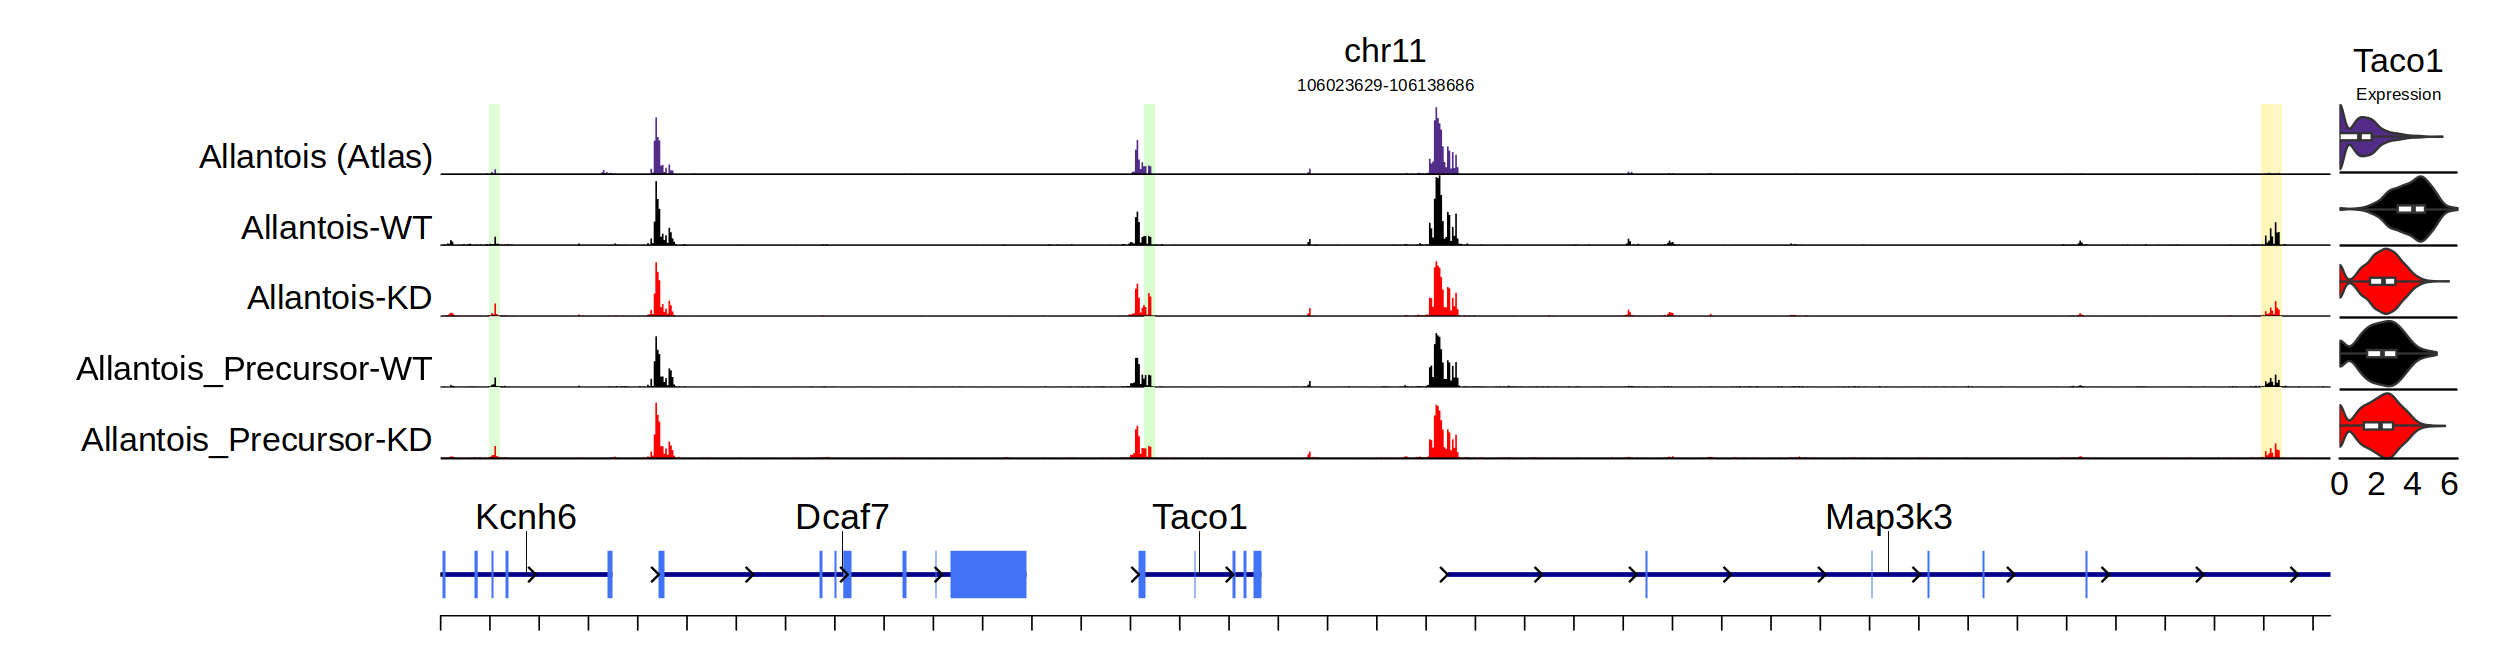

In [48]:
plot_region('Taco1')

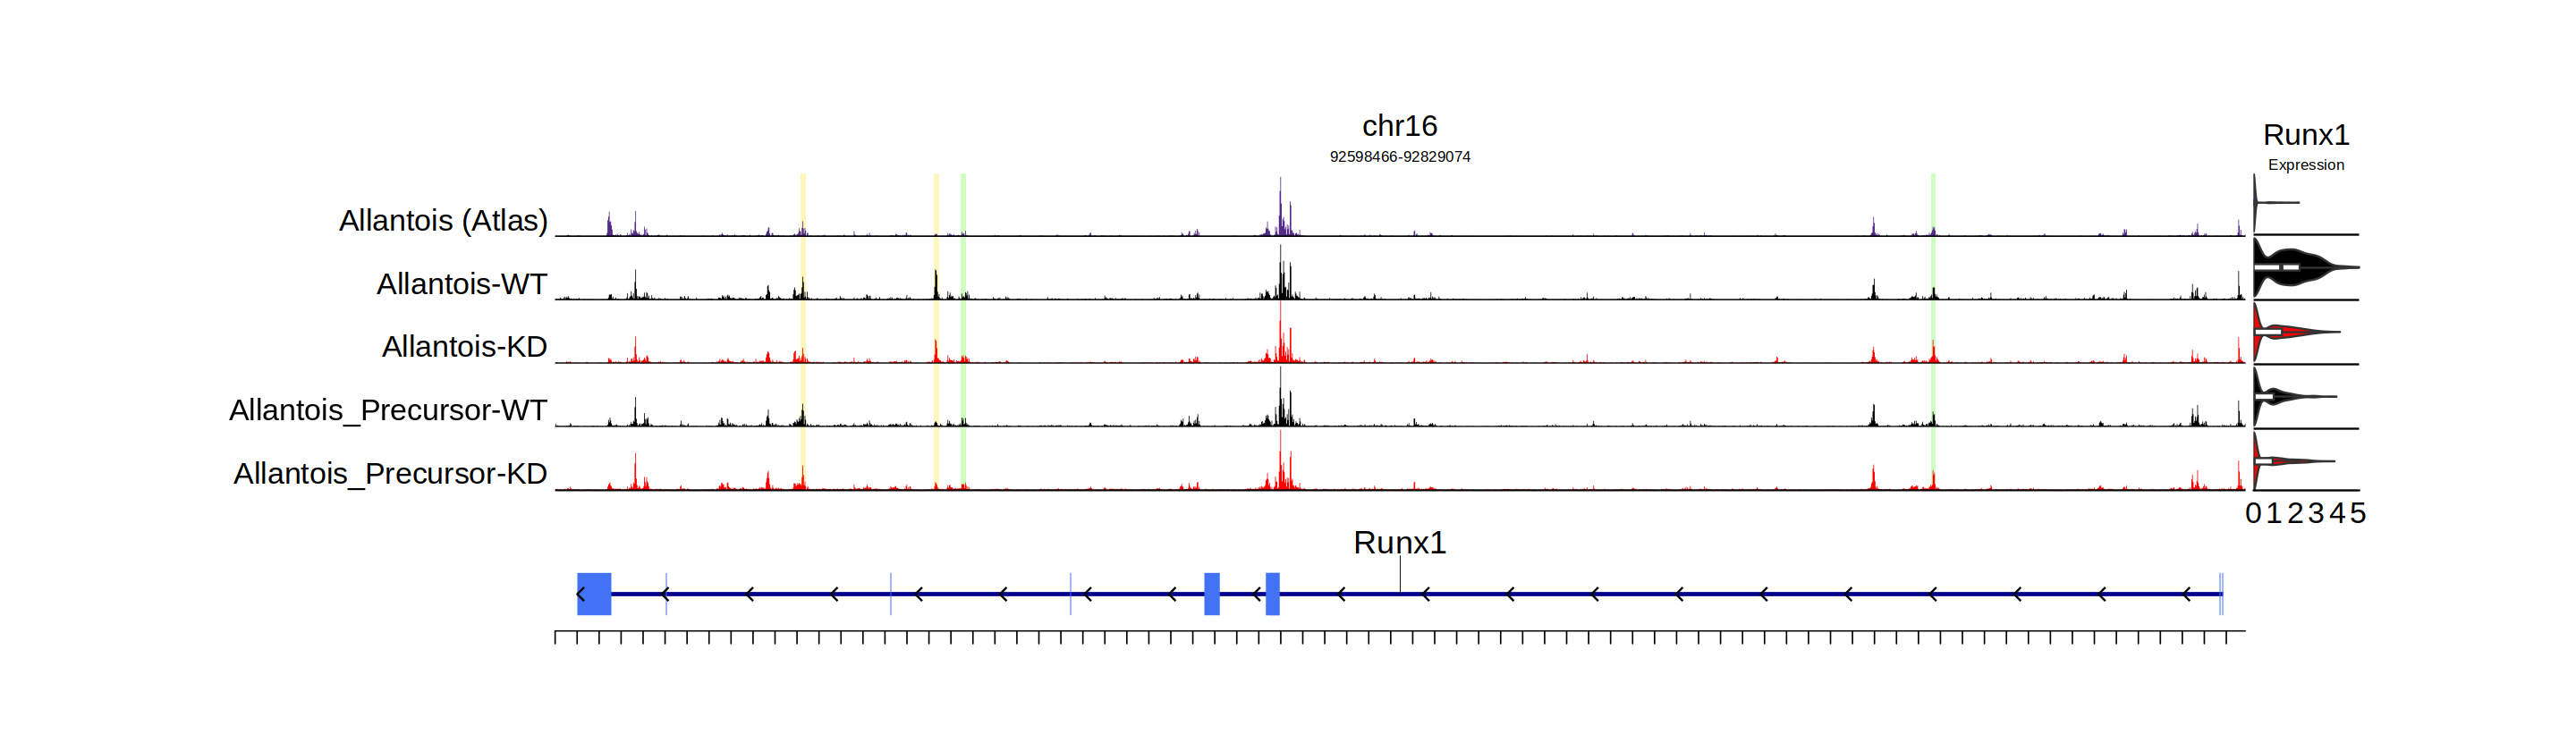

In [23]:
plot_region('Runx1')

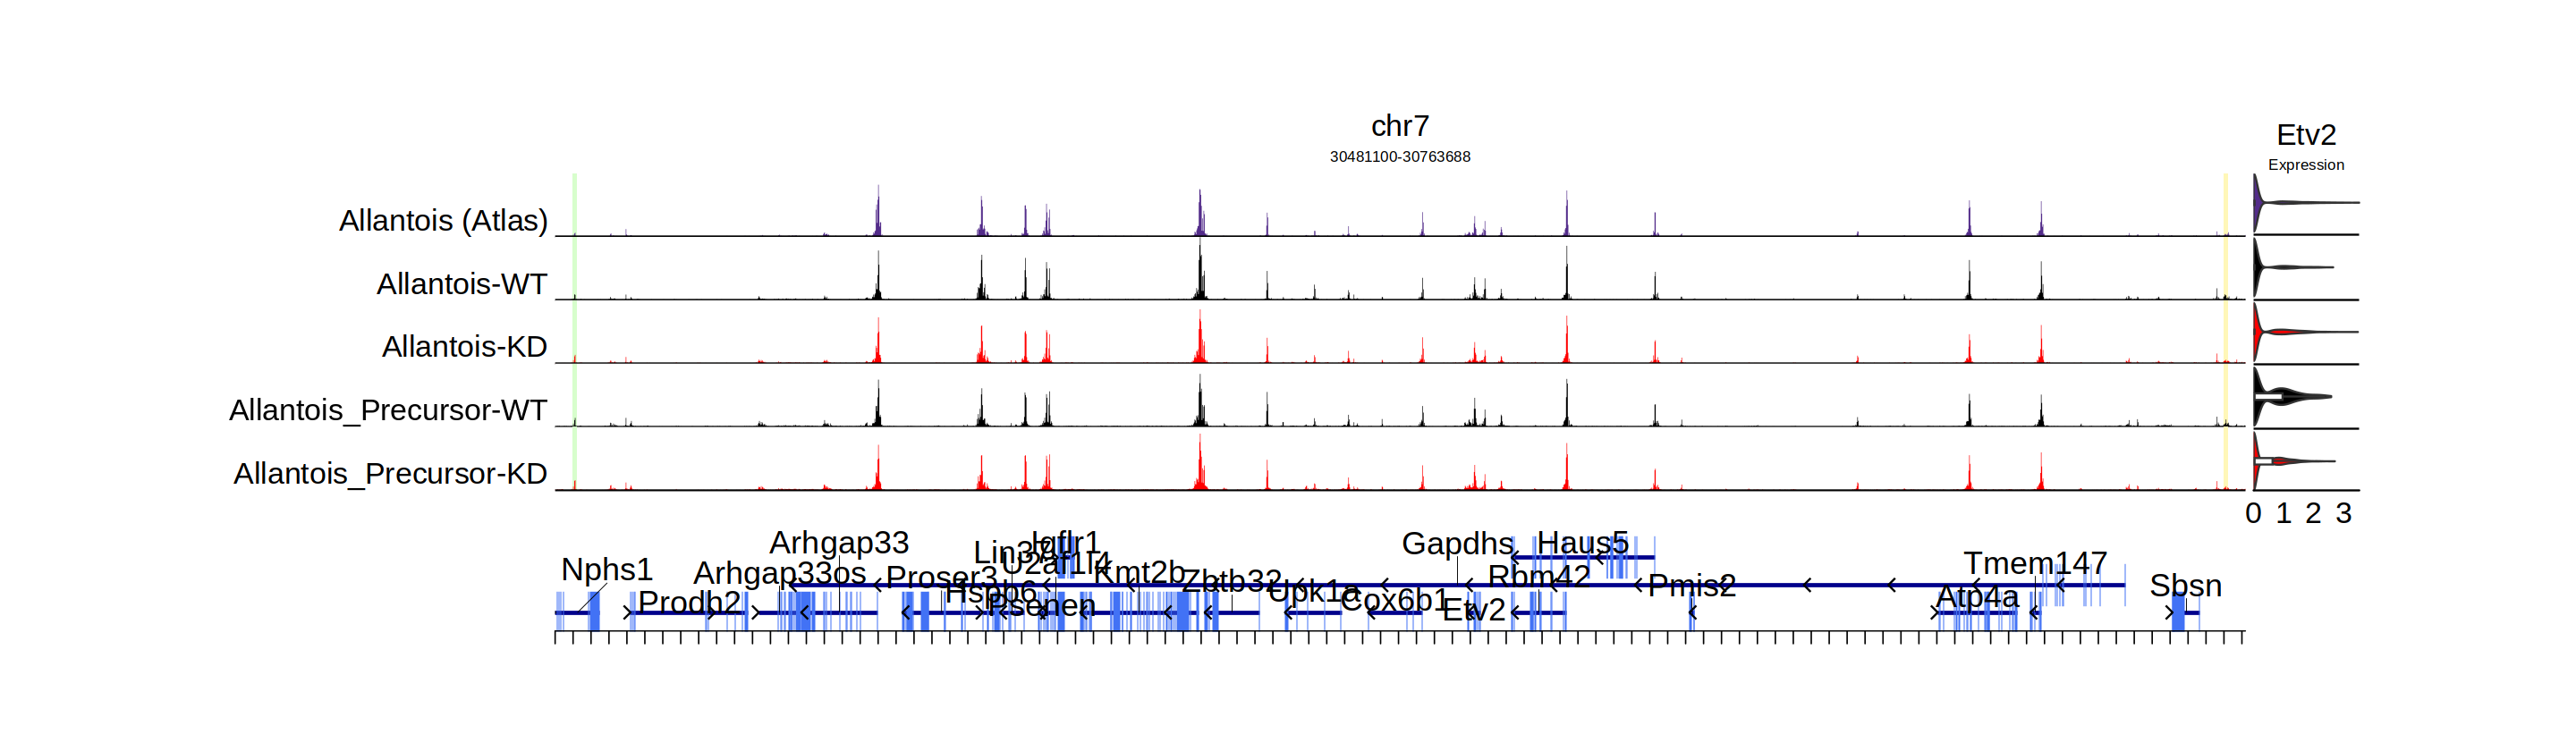

In [24]:
plot_region('Etv2')

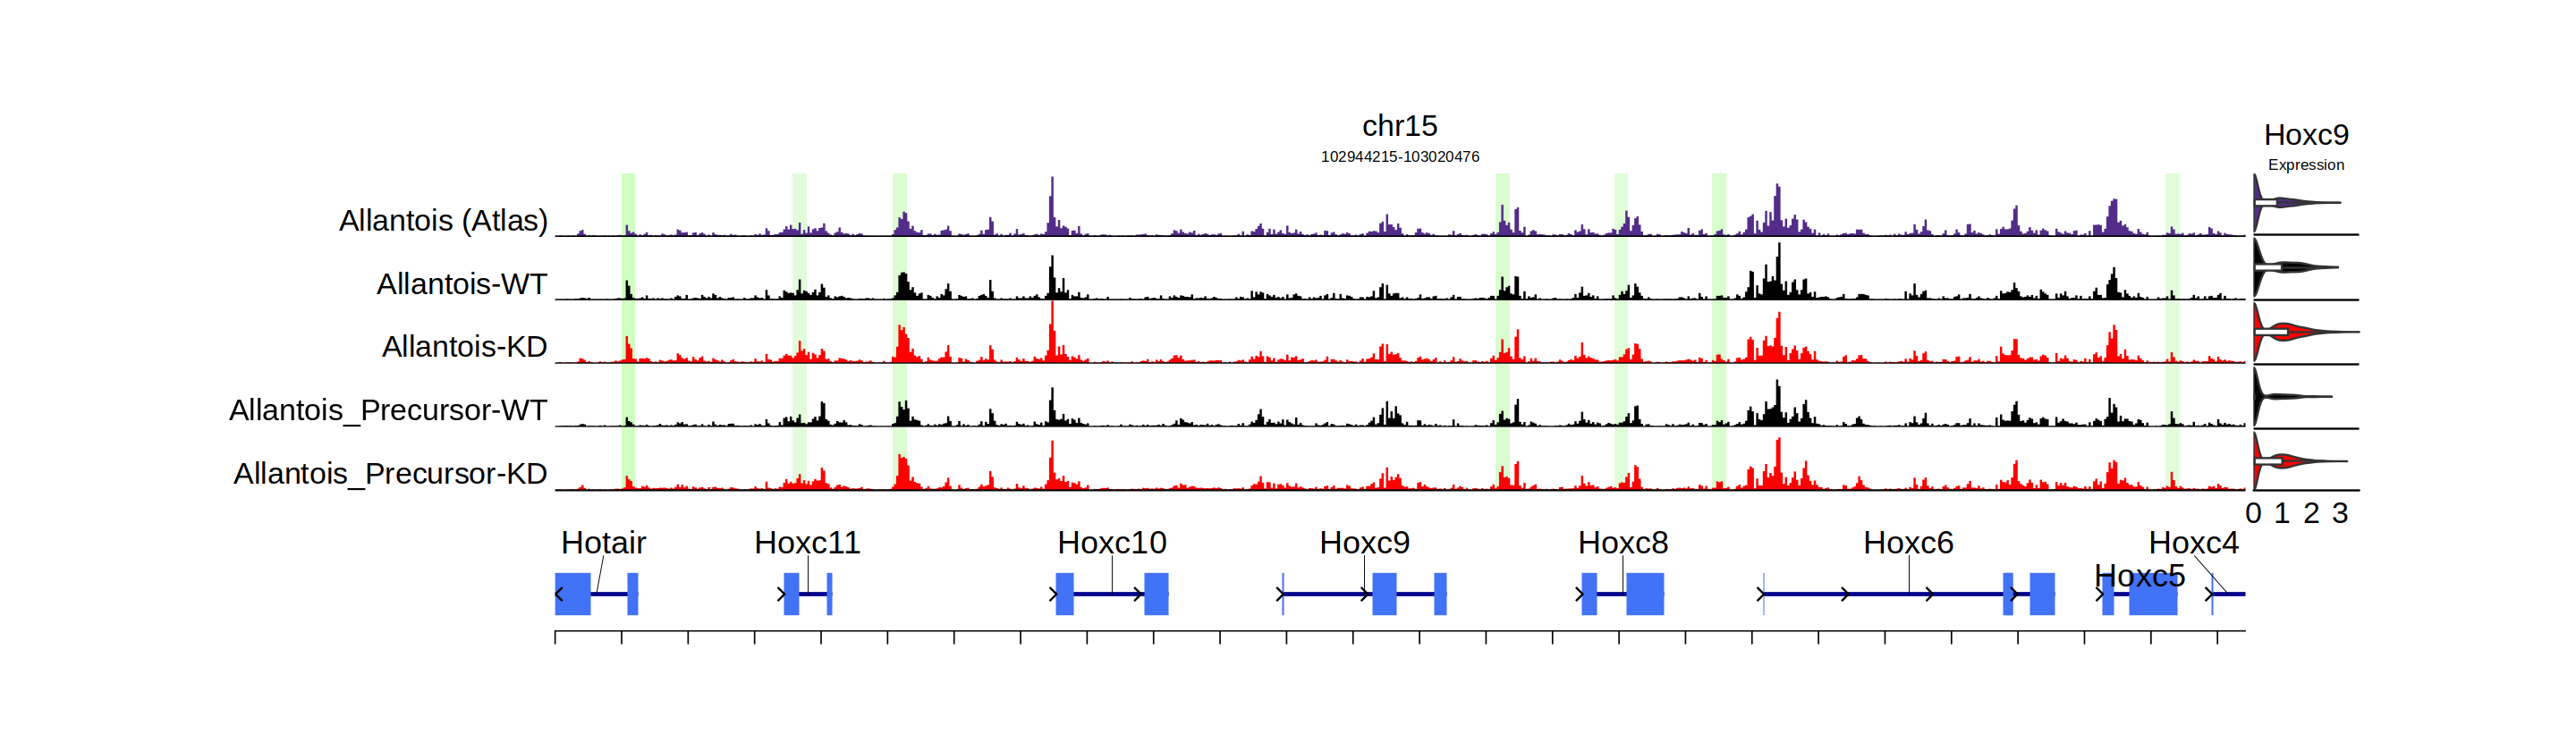

In [25]:
plot_region('Hoxc9')

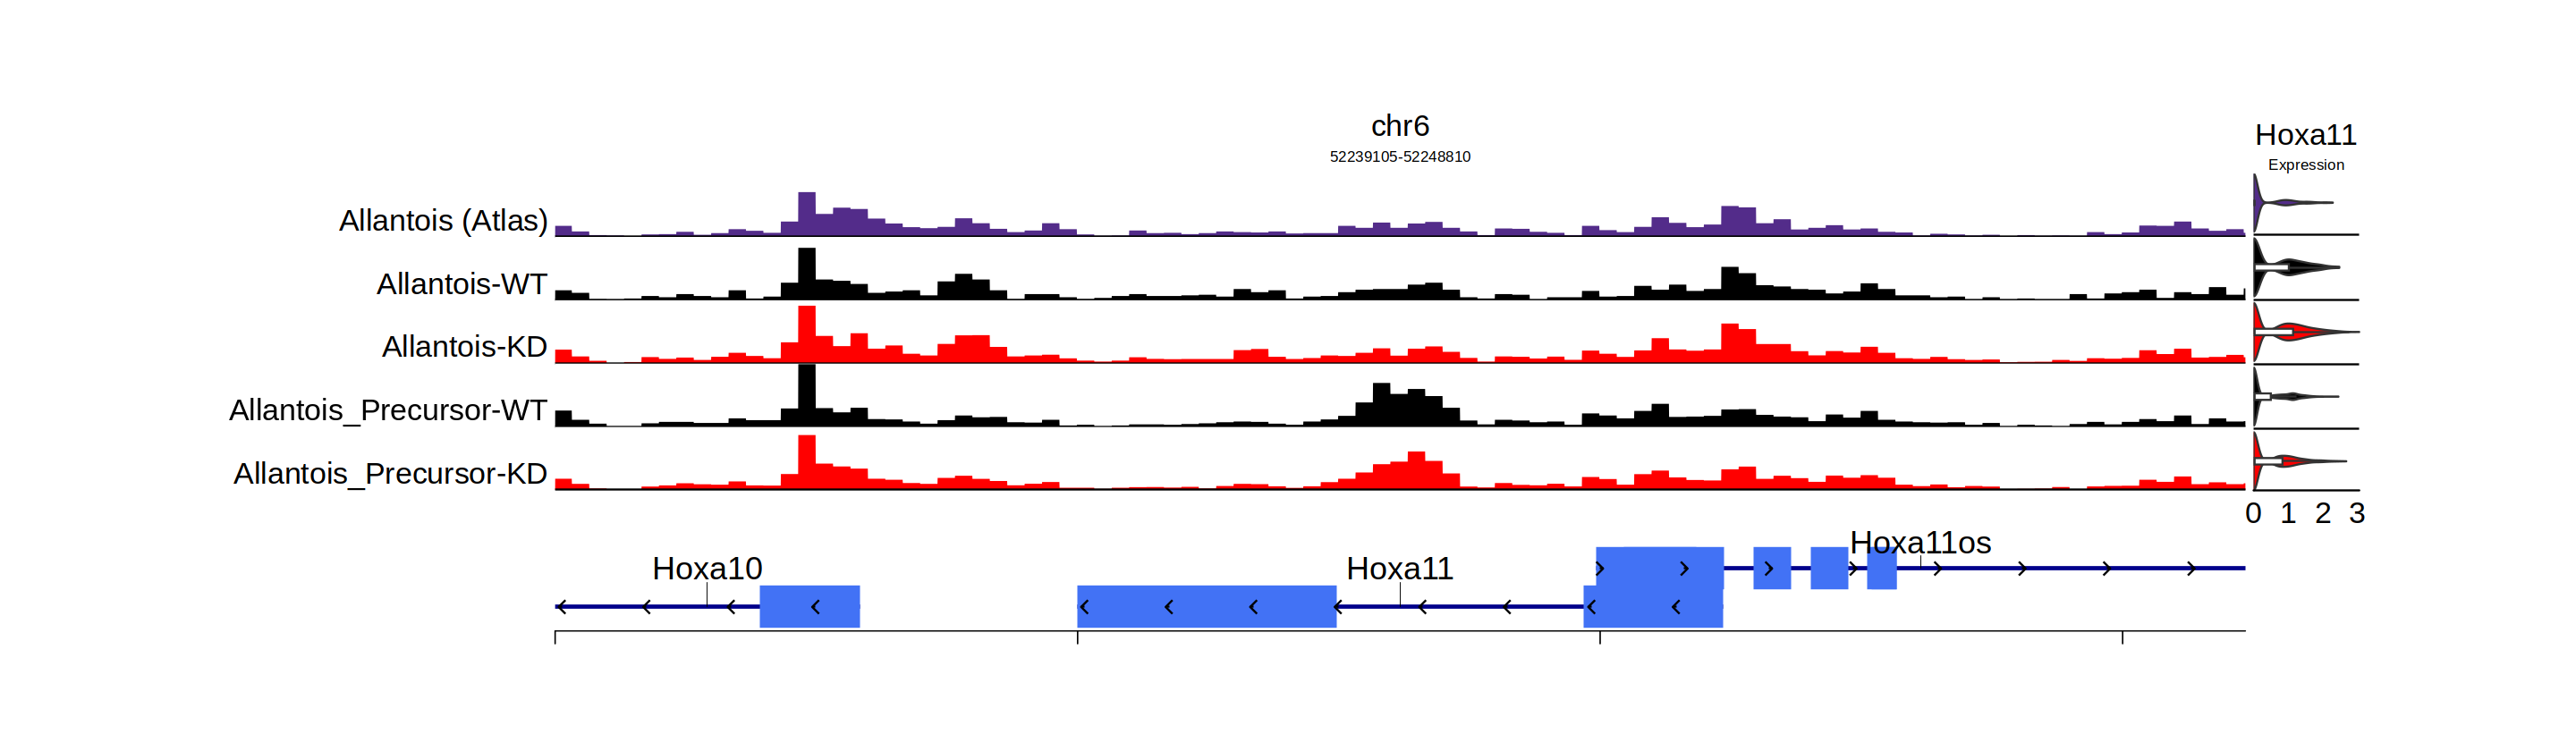

In [26]:
plot_region('Hoxa11')

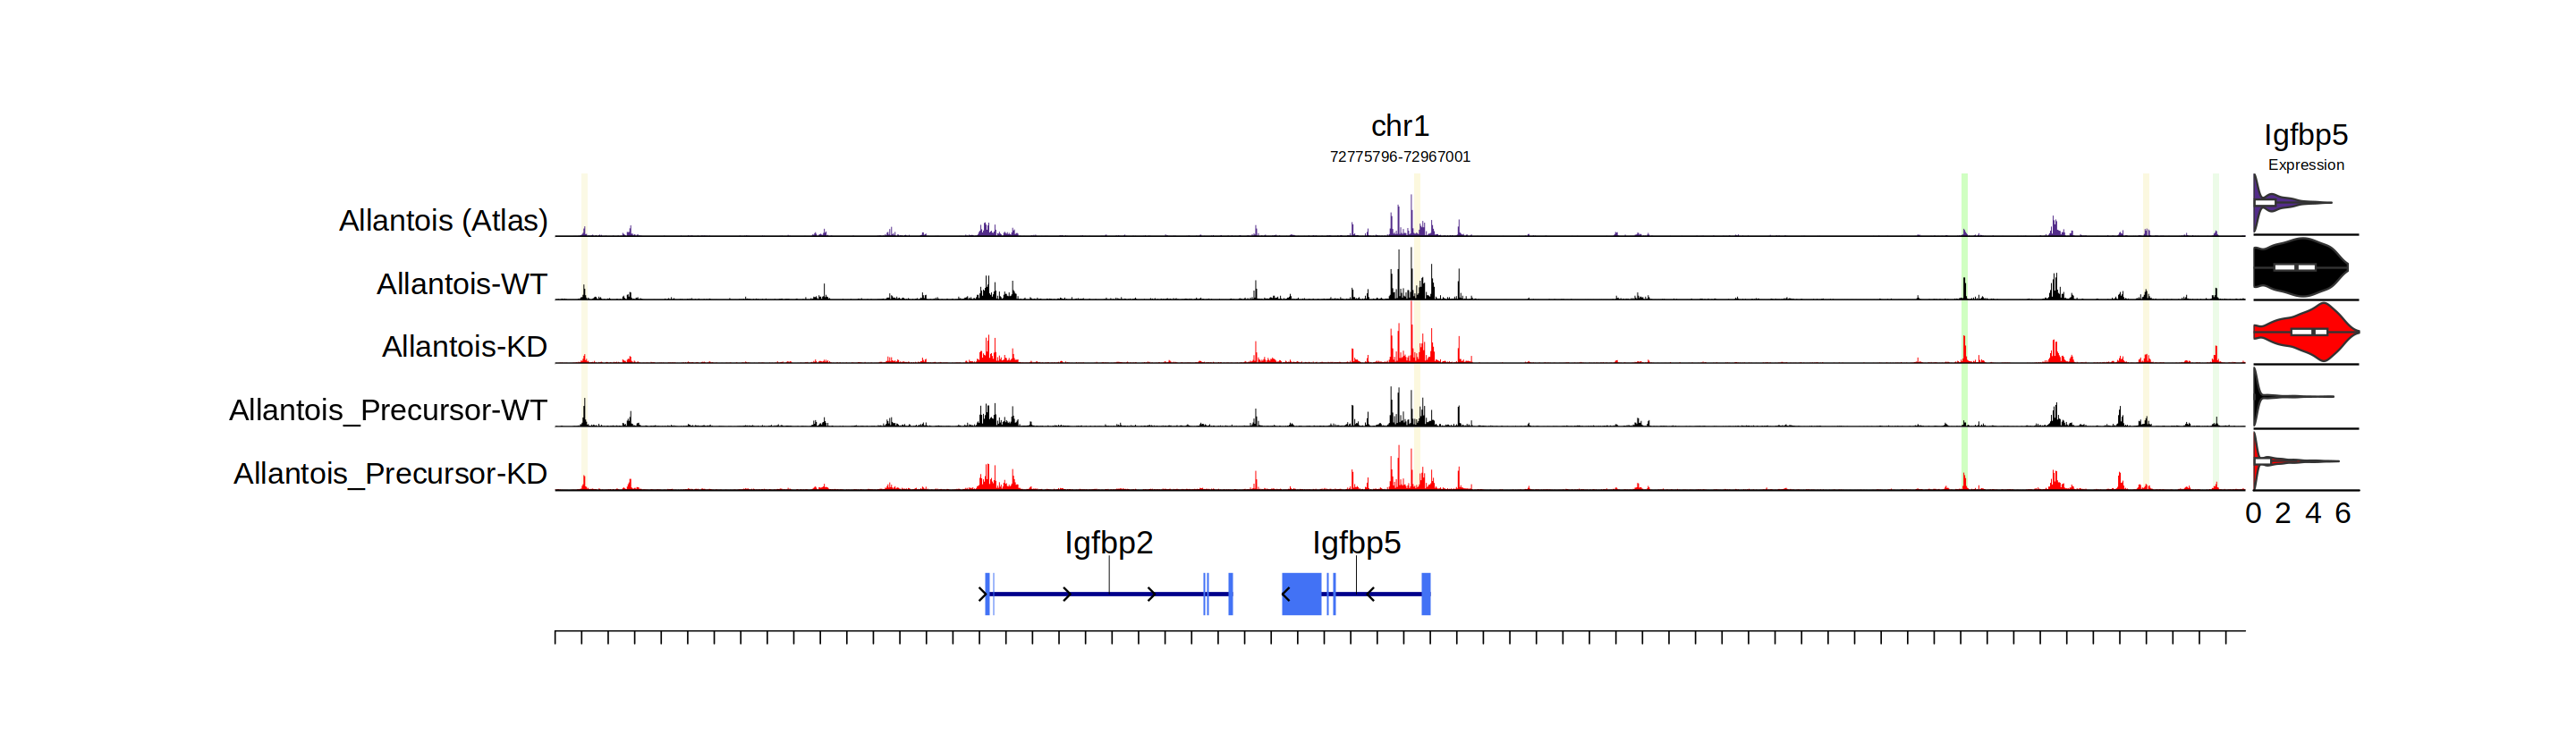

In [27]:
plot_region('Igfbp5')

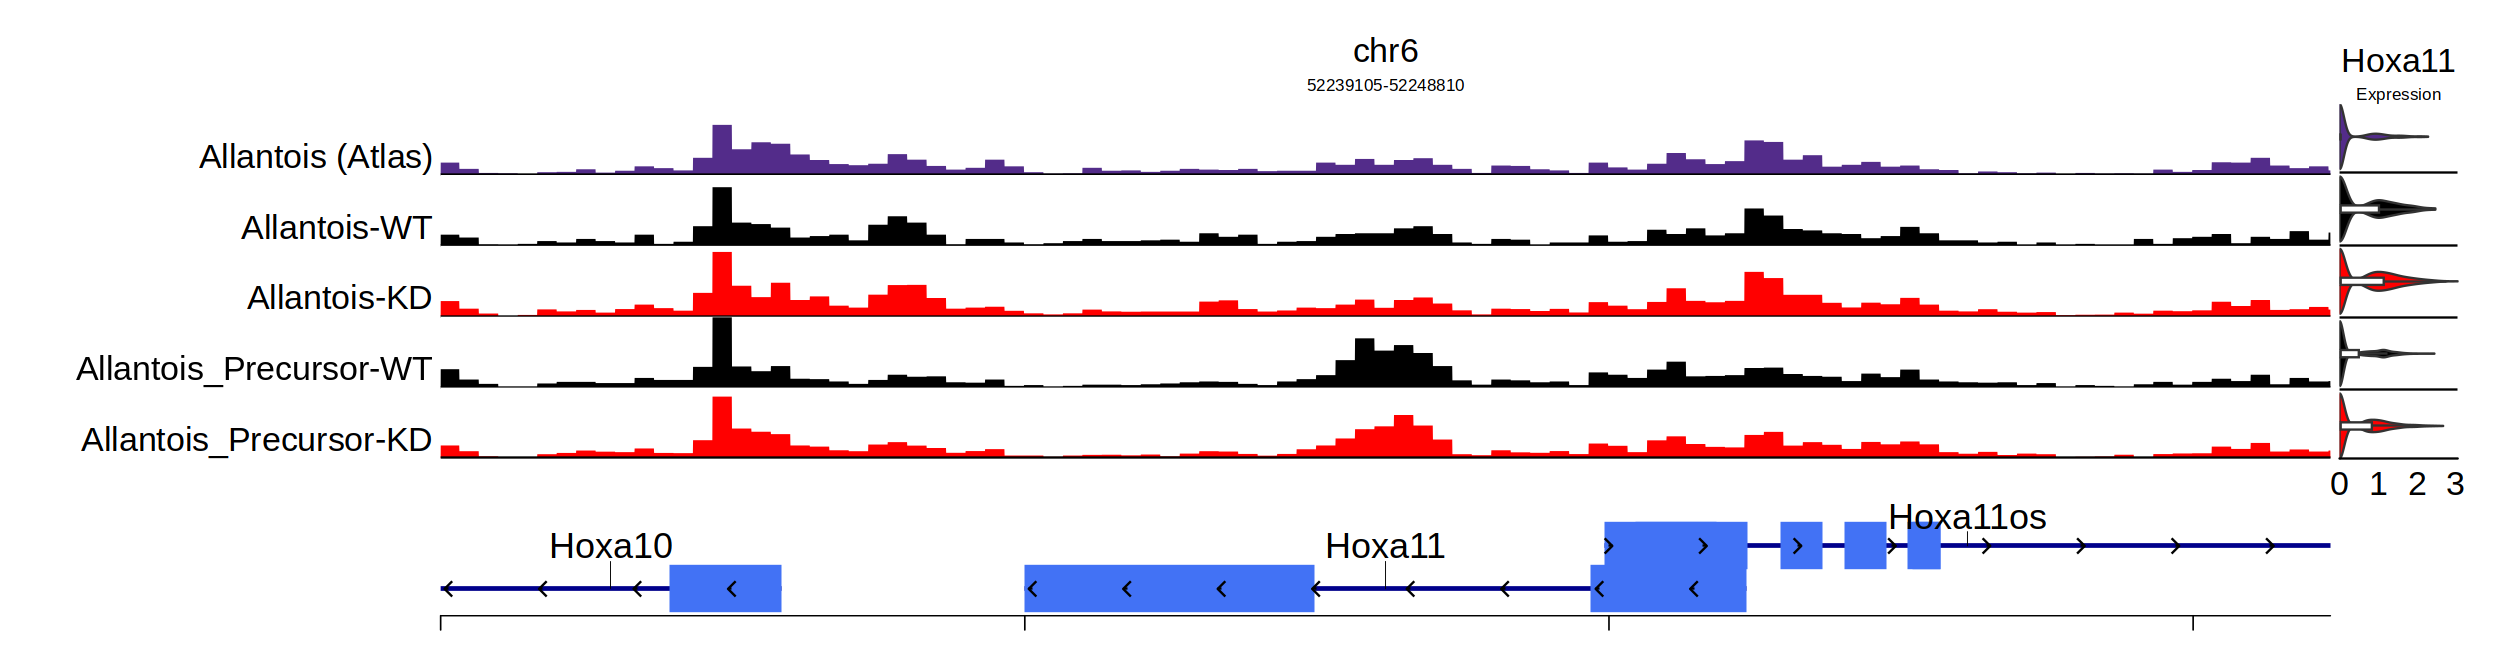

In [33]:
options(repr.plot.width=21, repr.plot.height=5.5)
plot_region('Hoxa11')

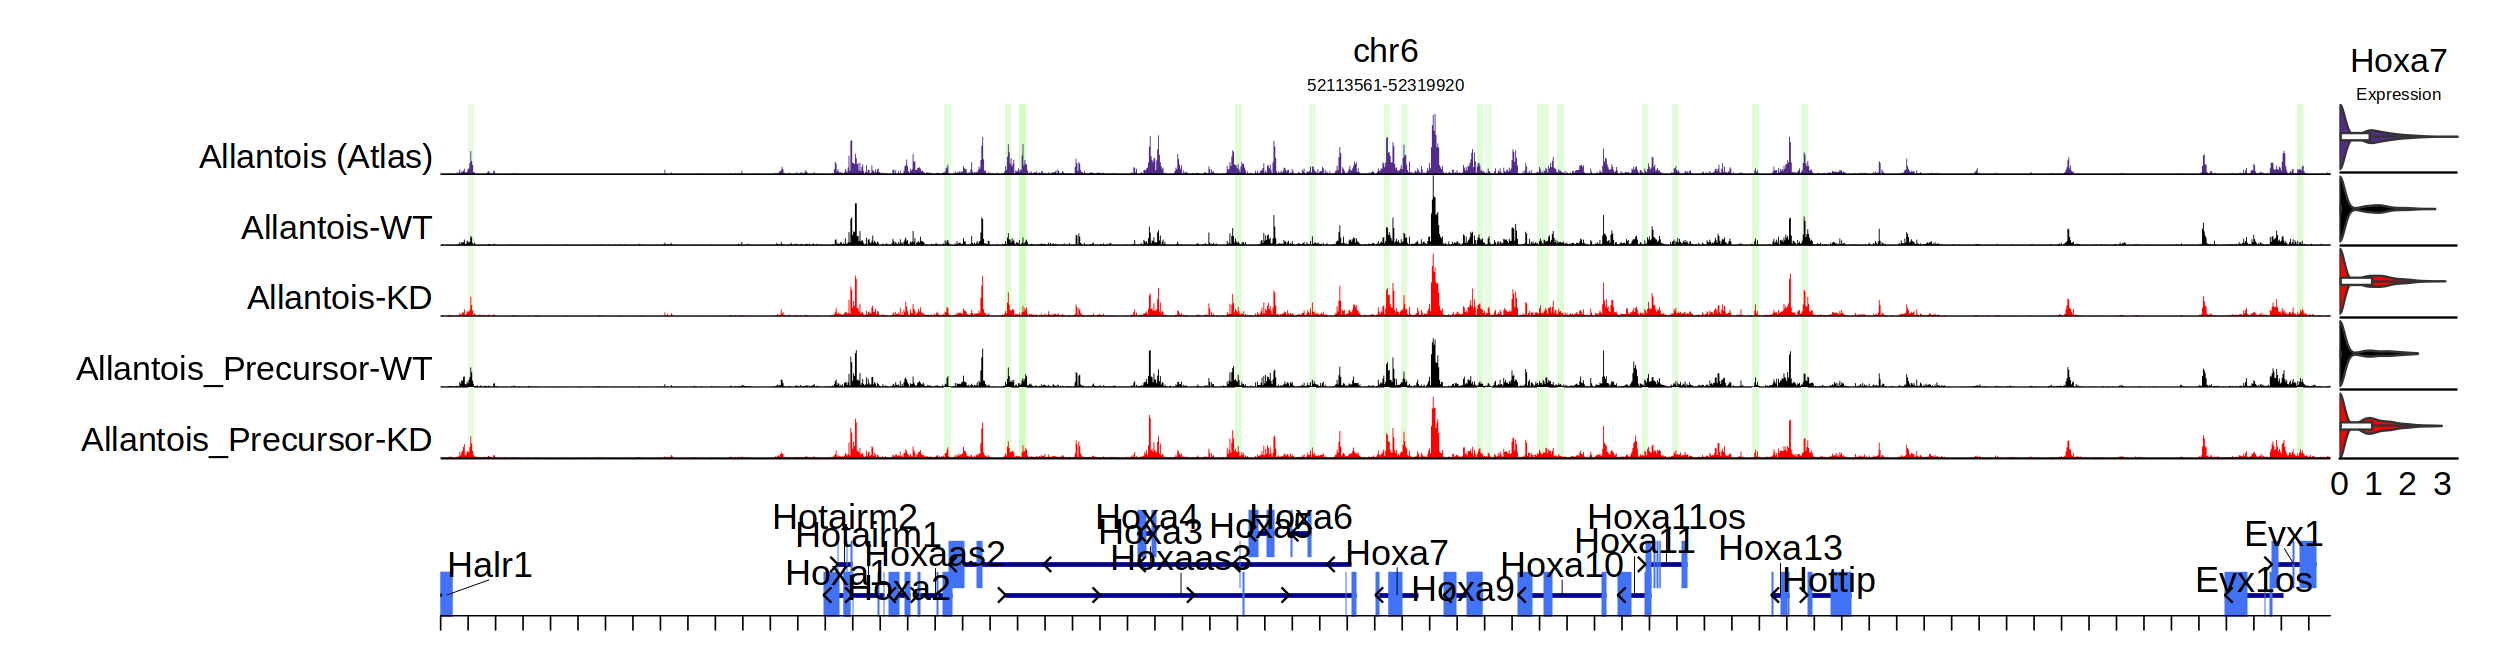

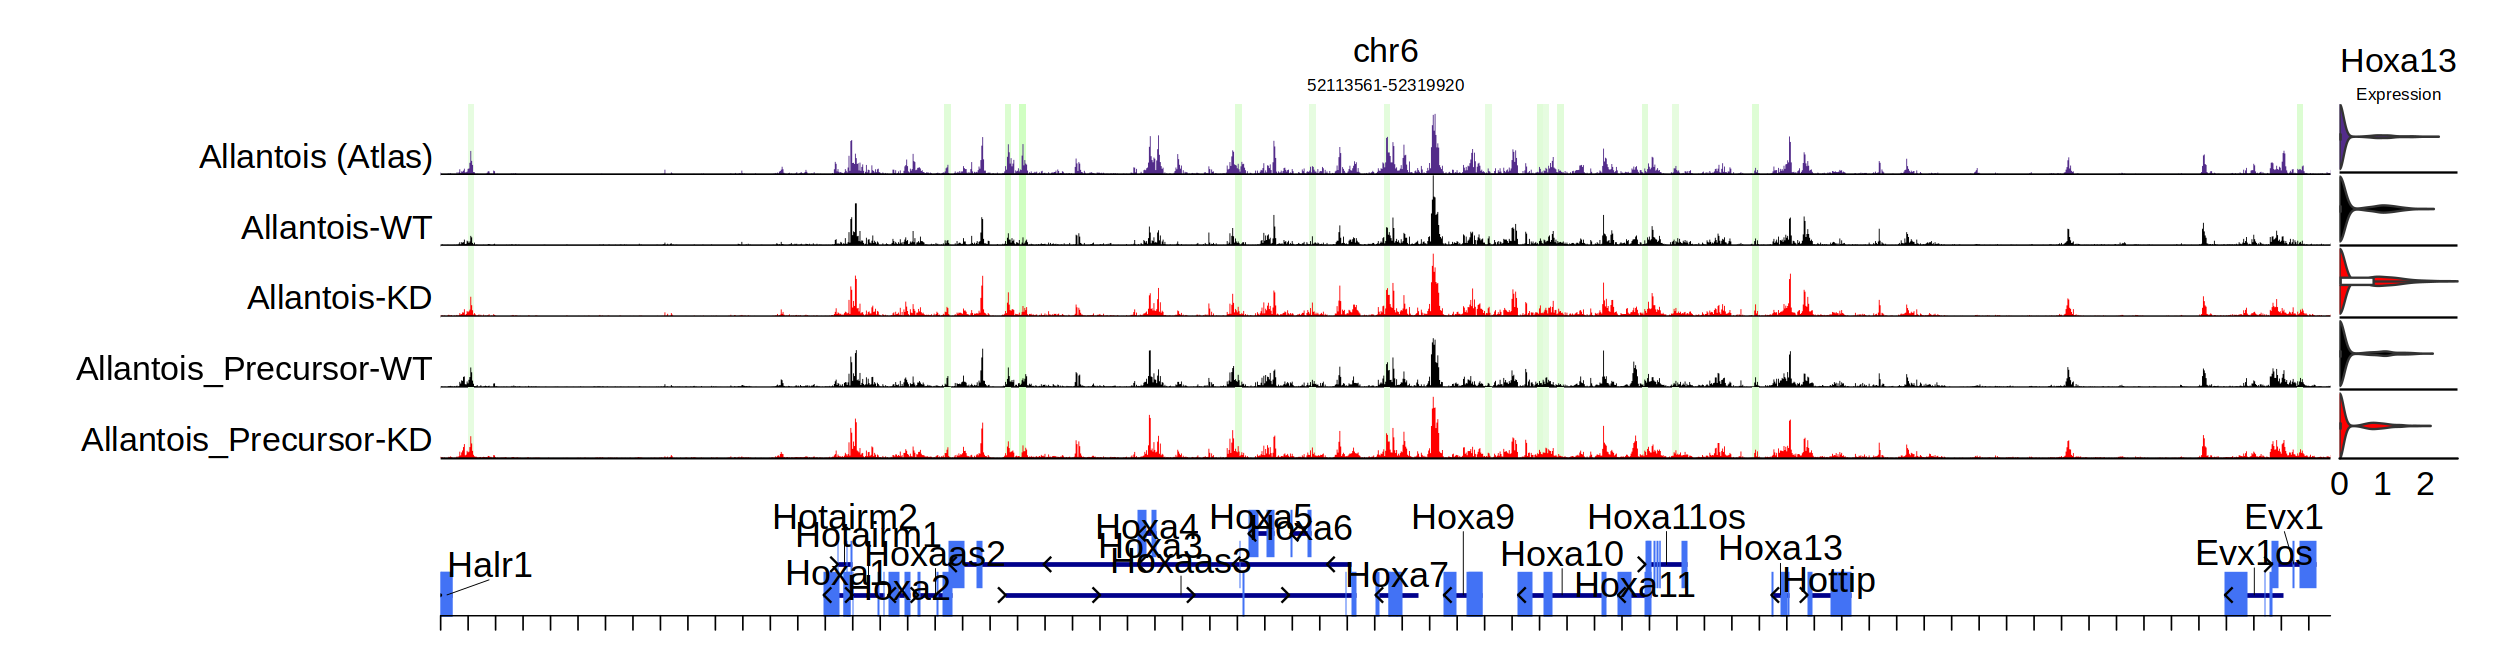

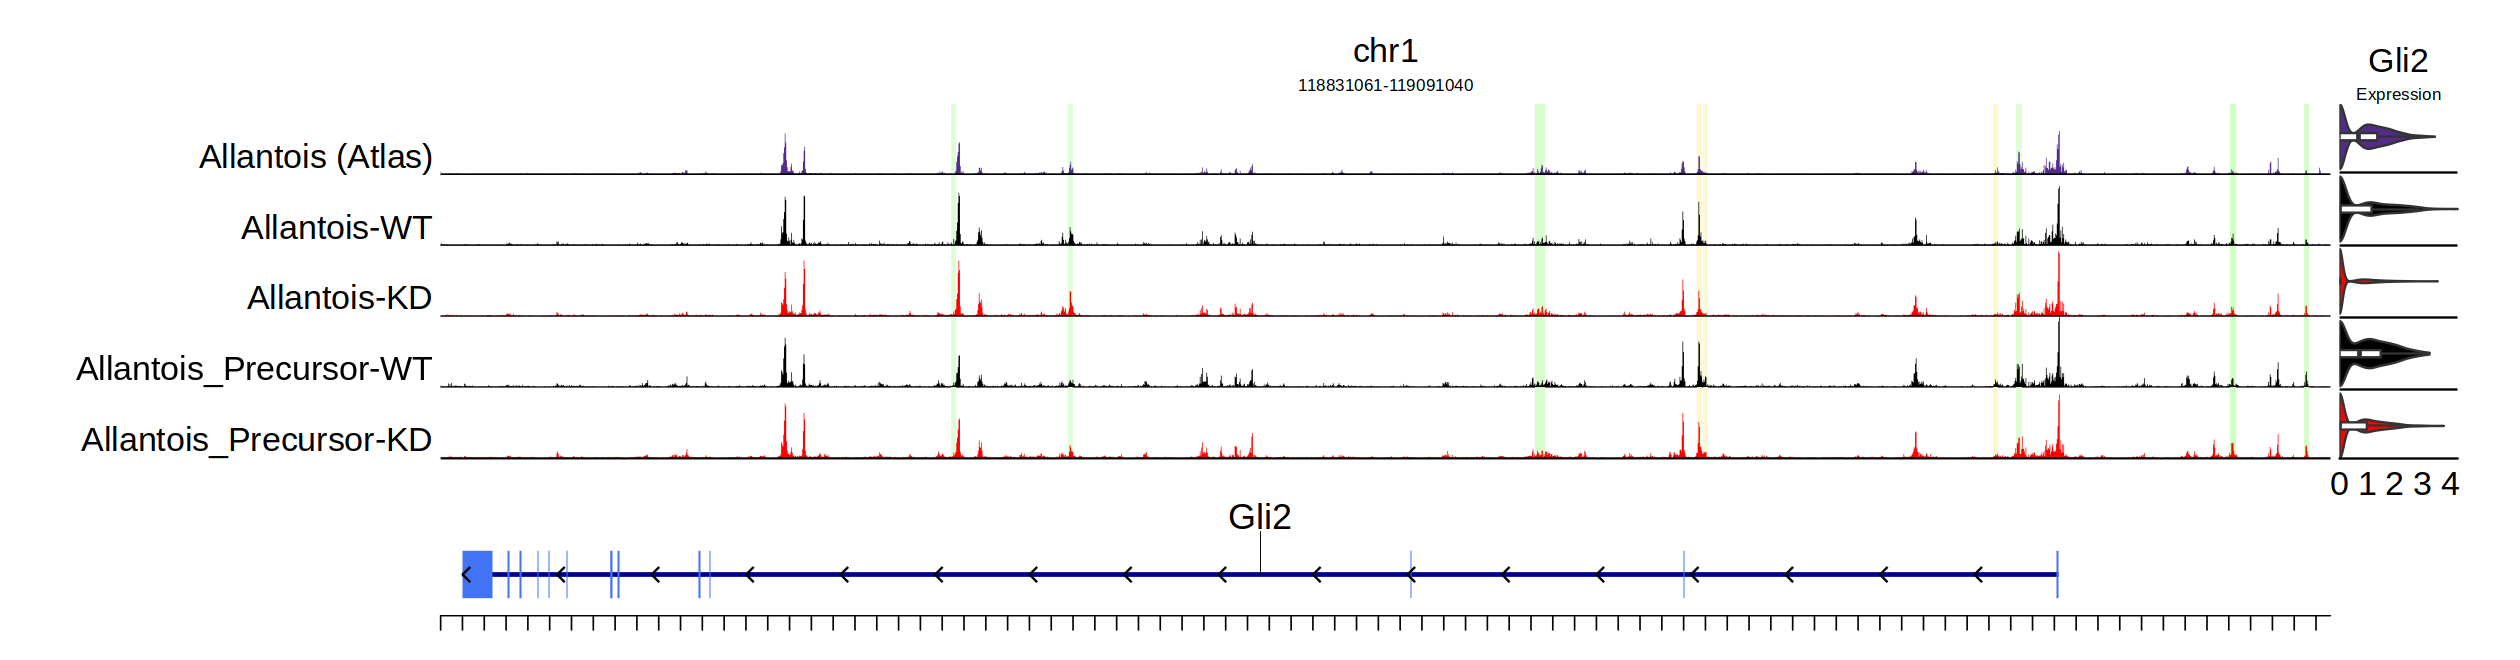

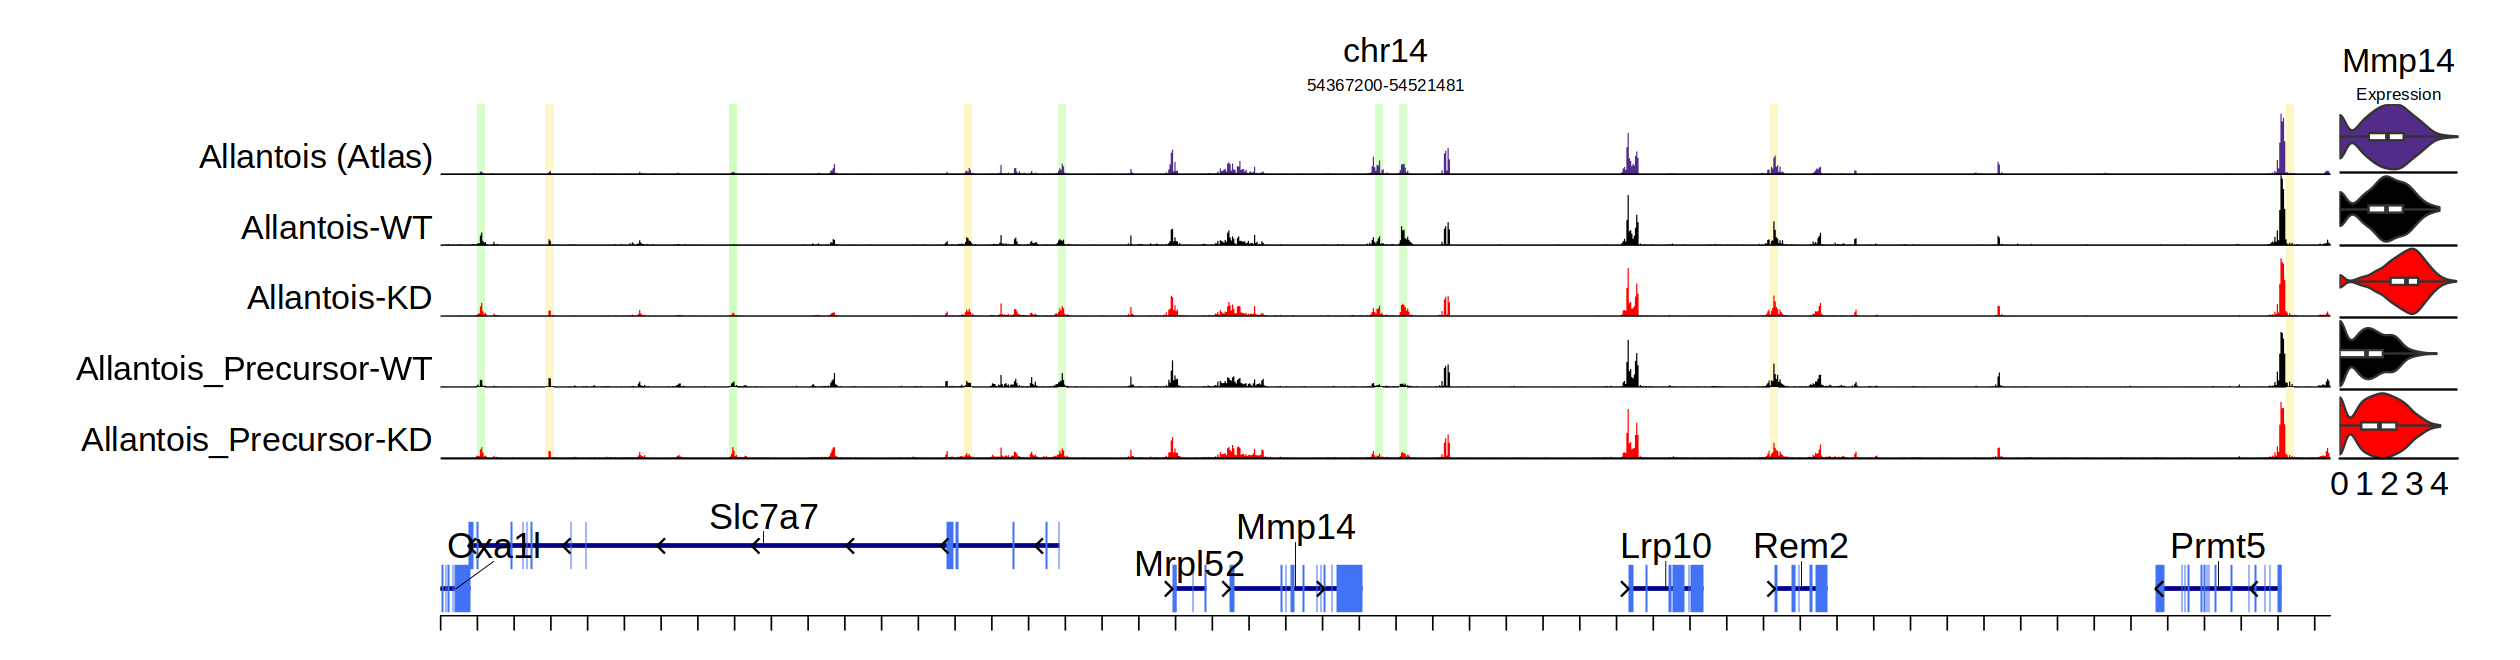

Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


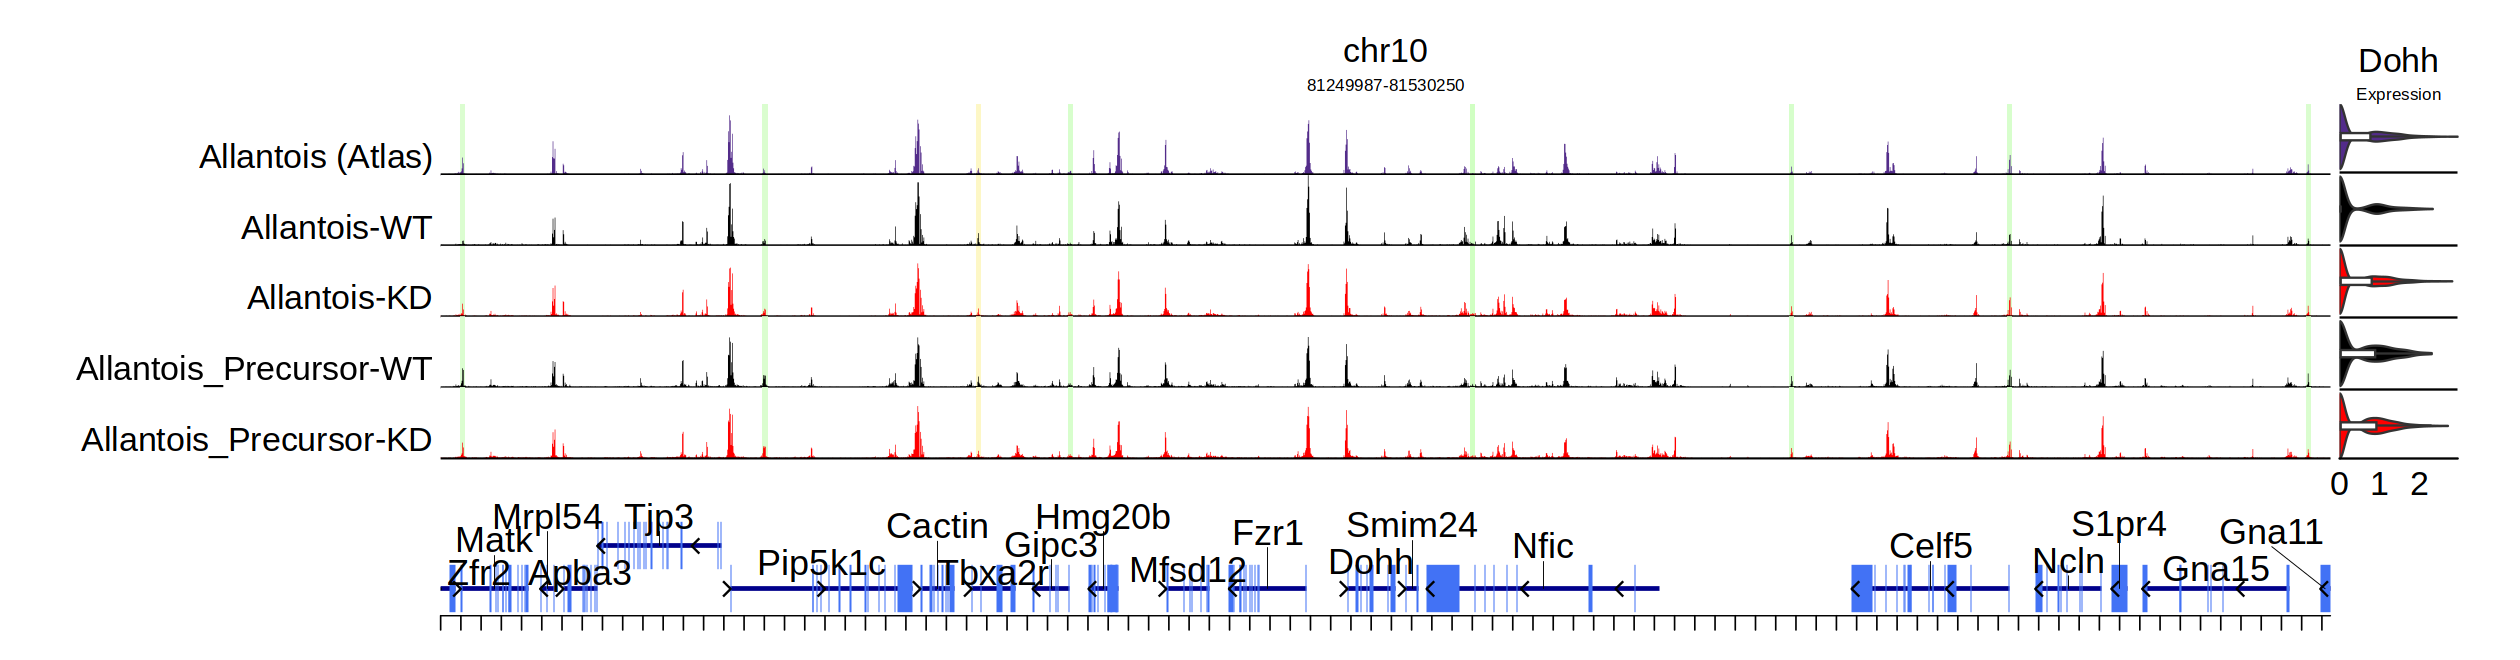

Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


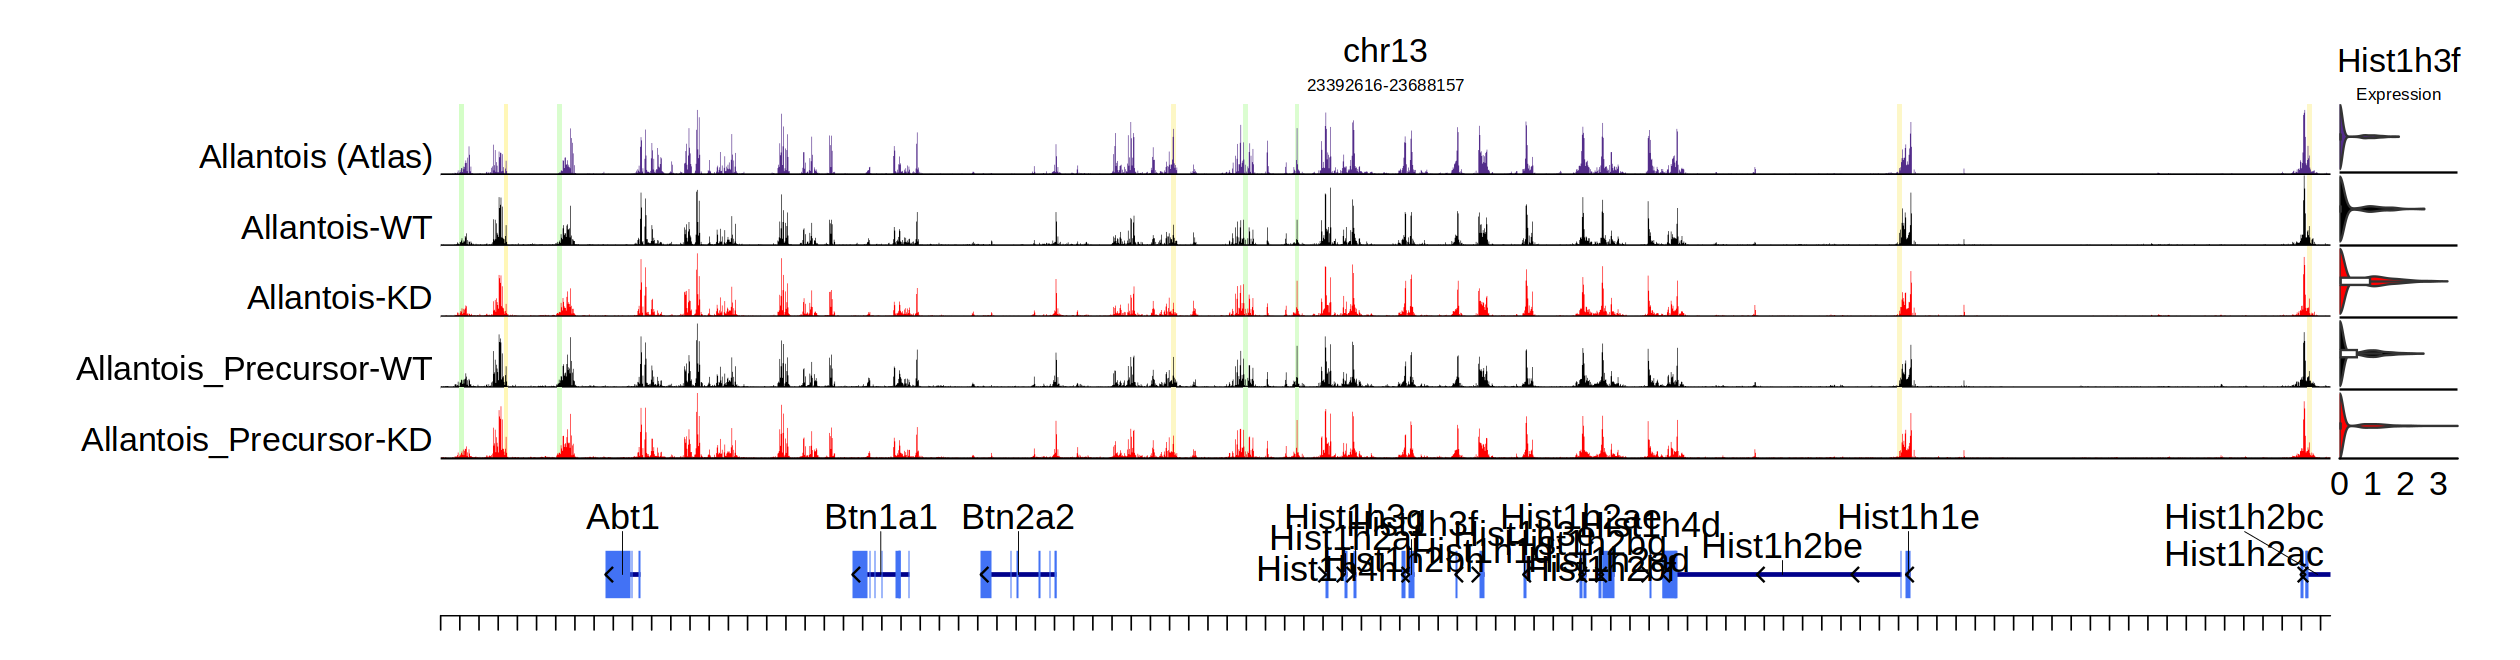

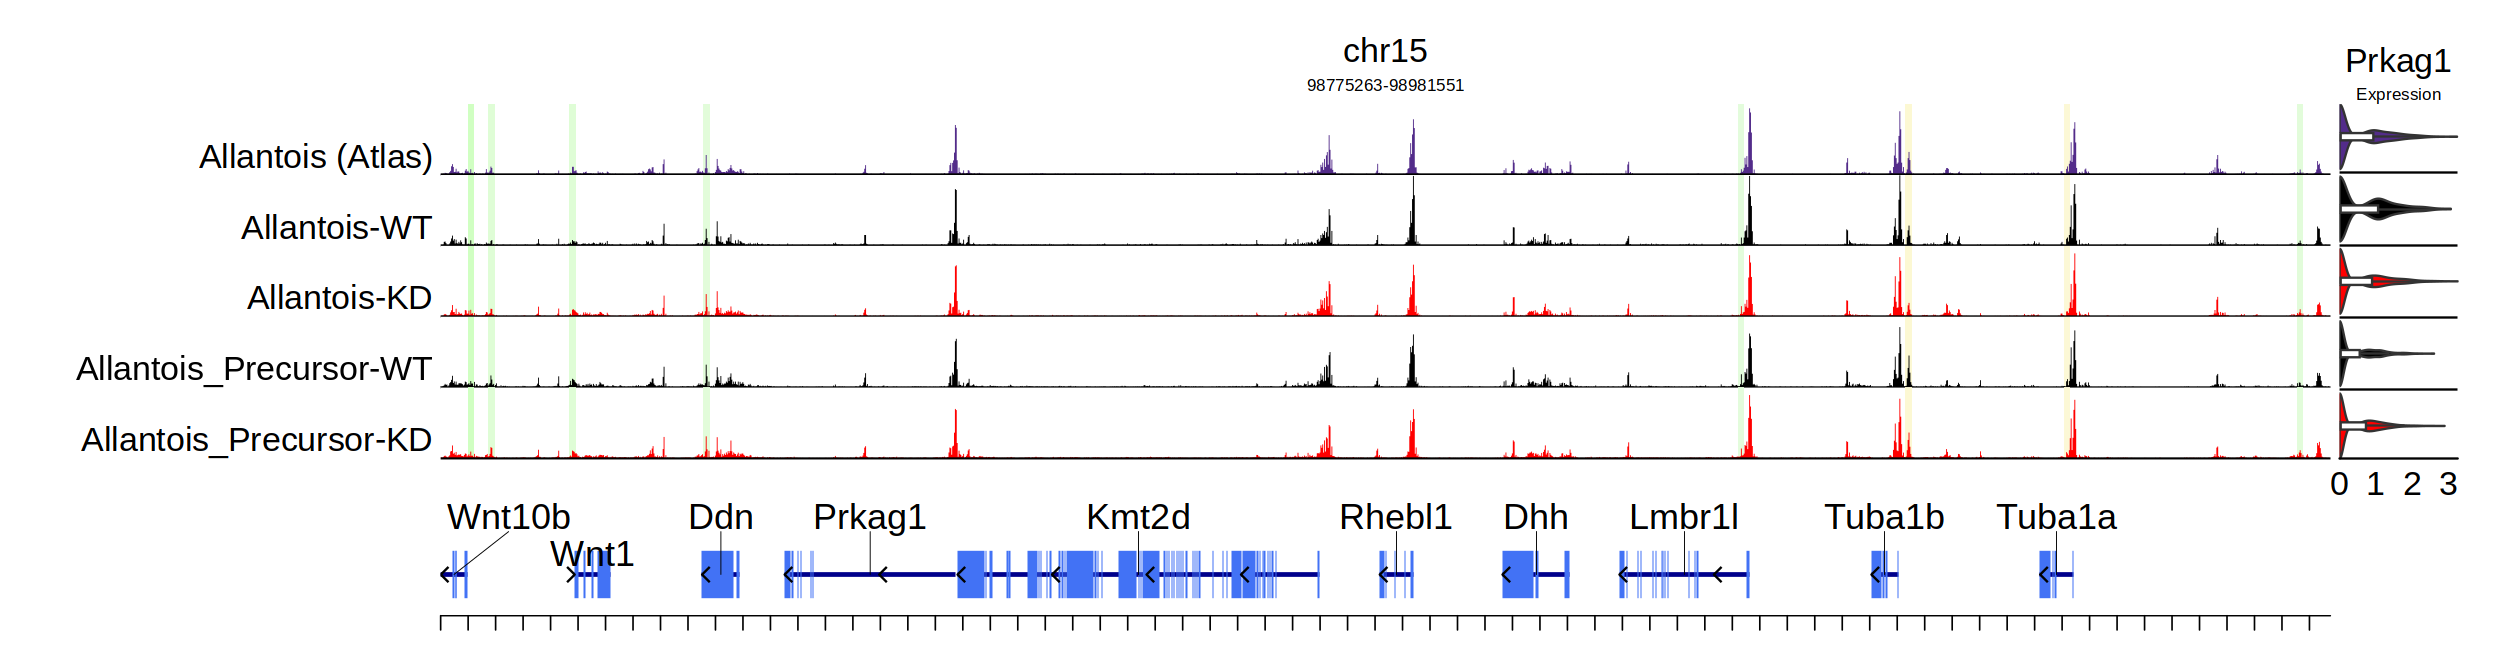

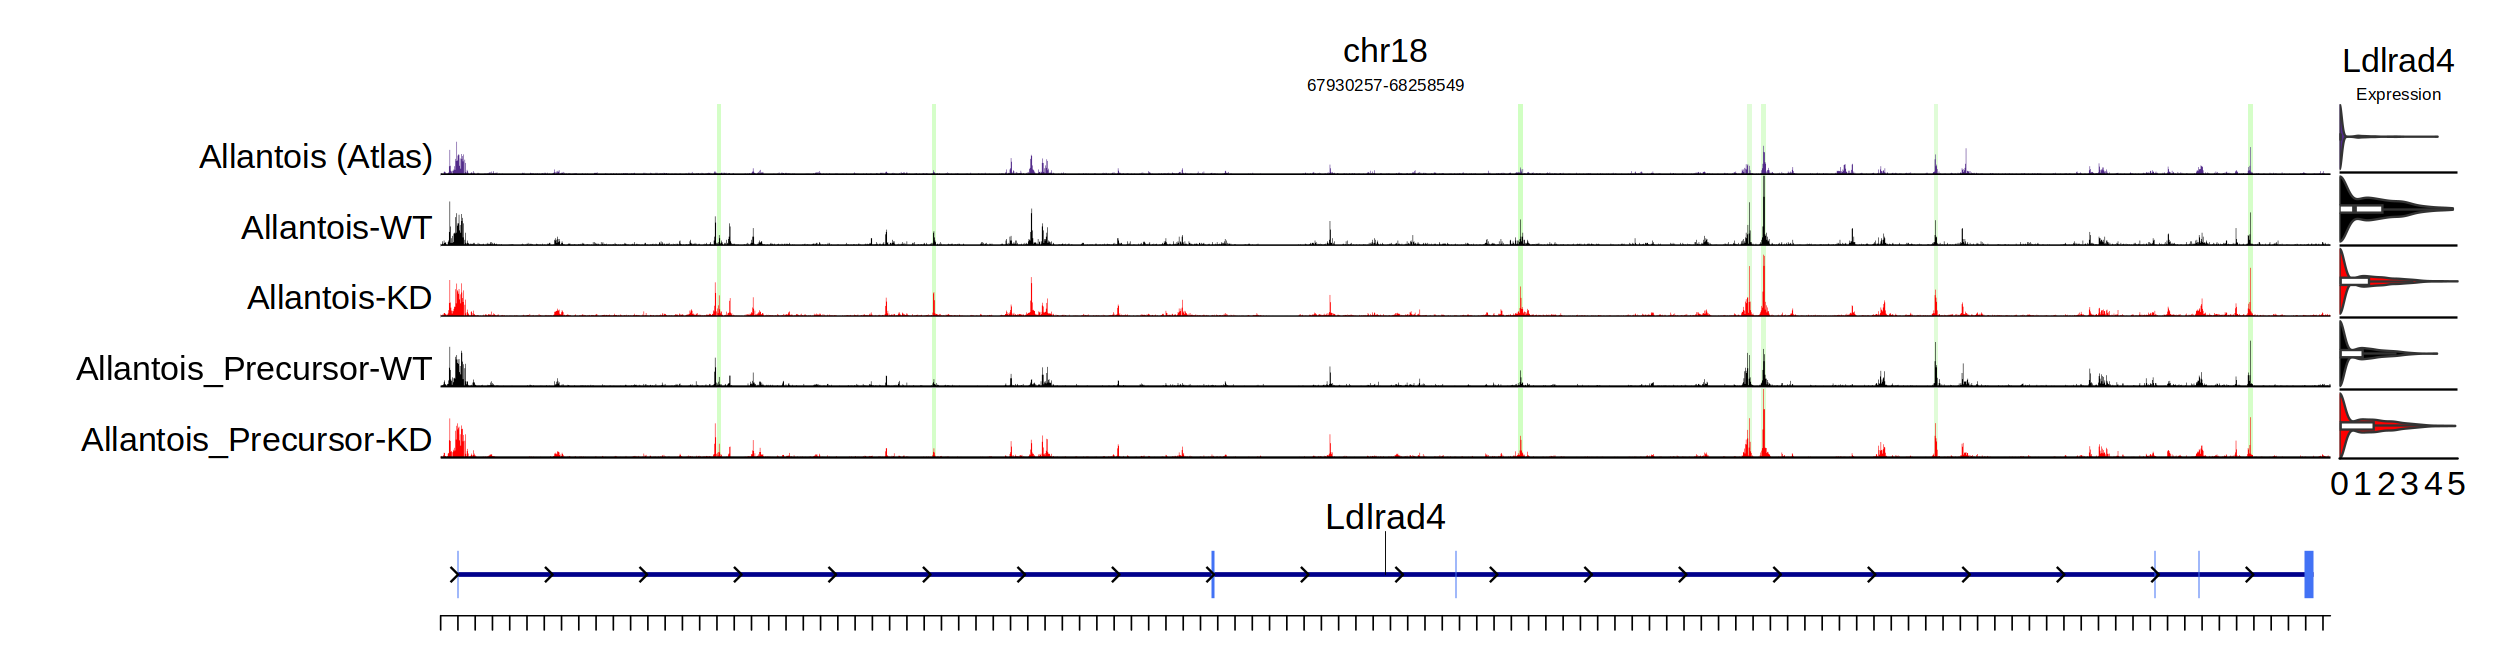

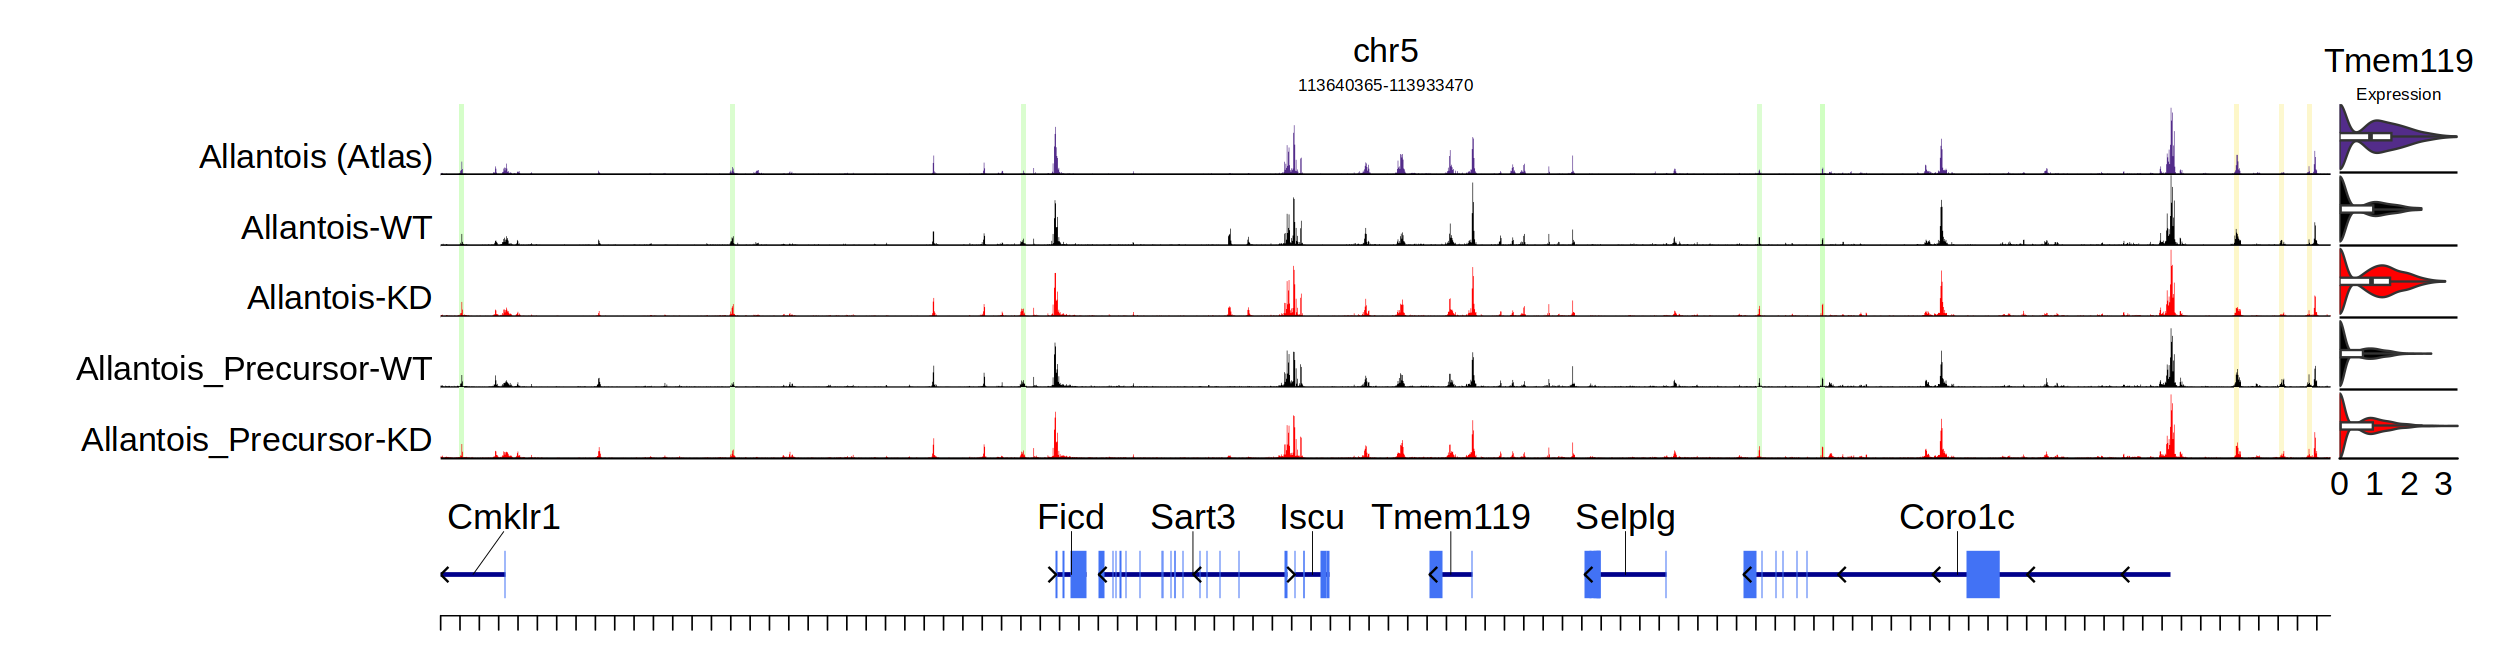

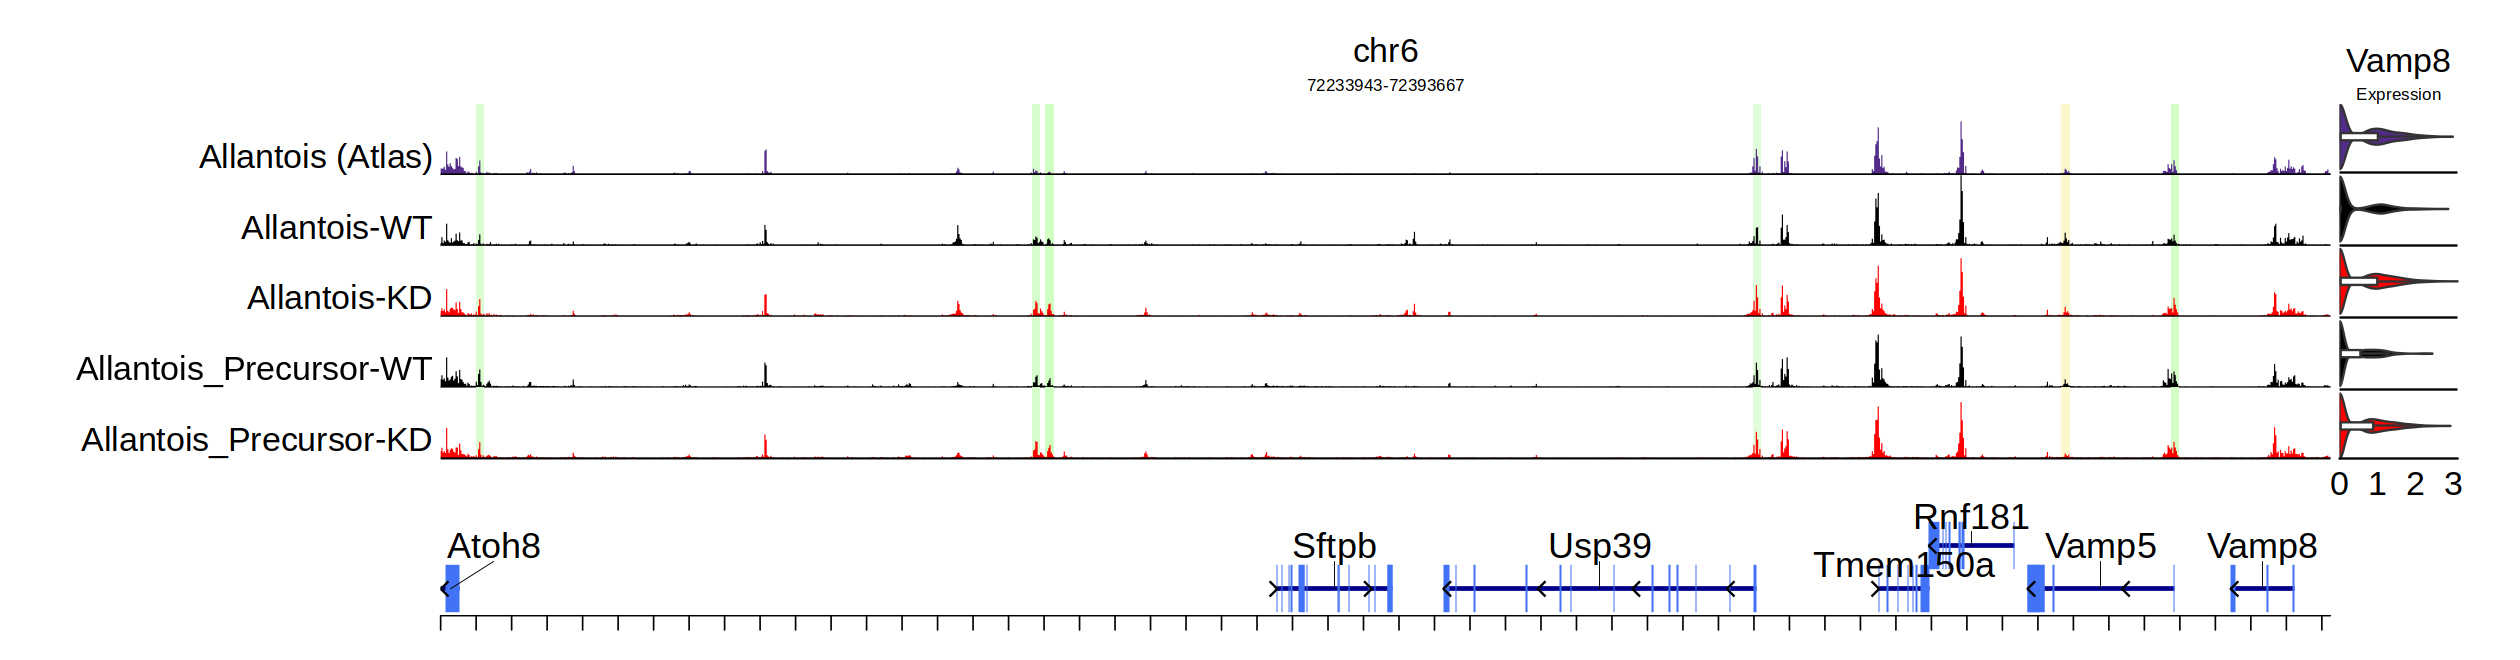

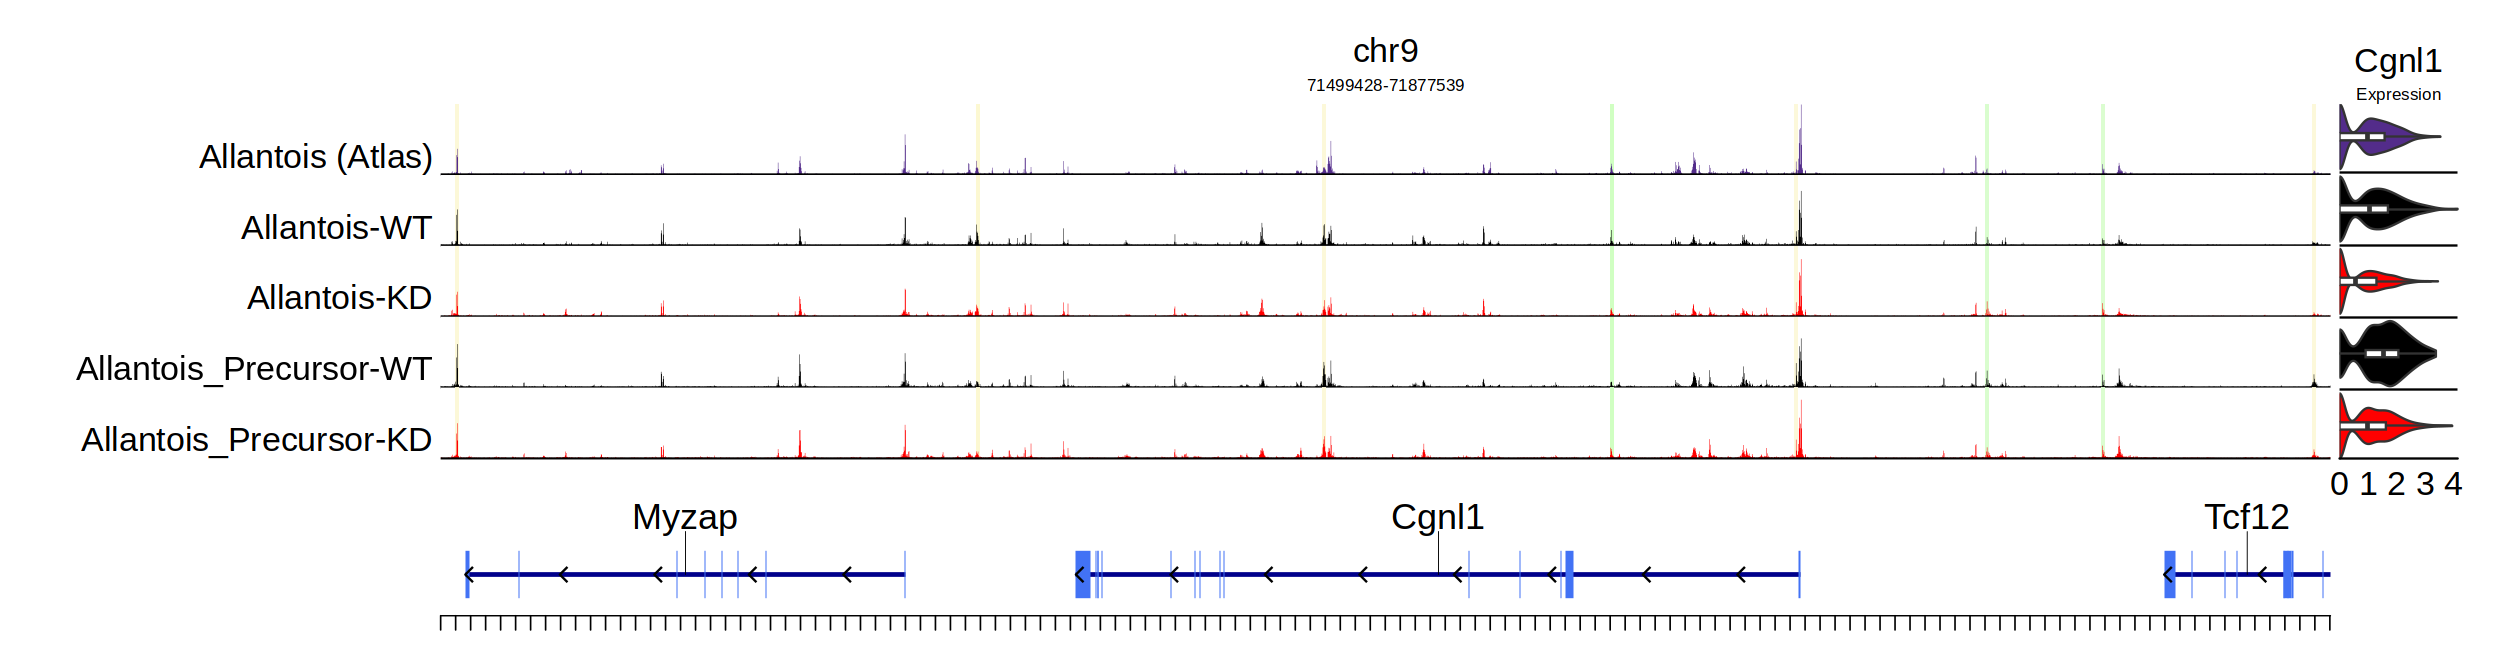

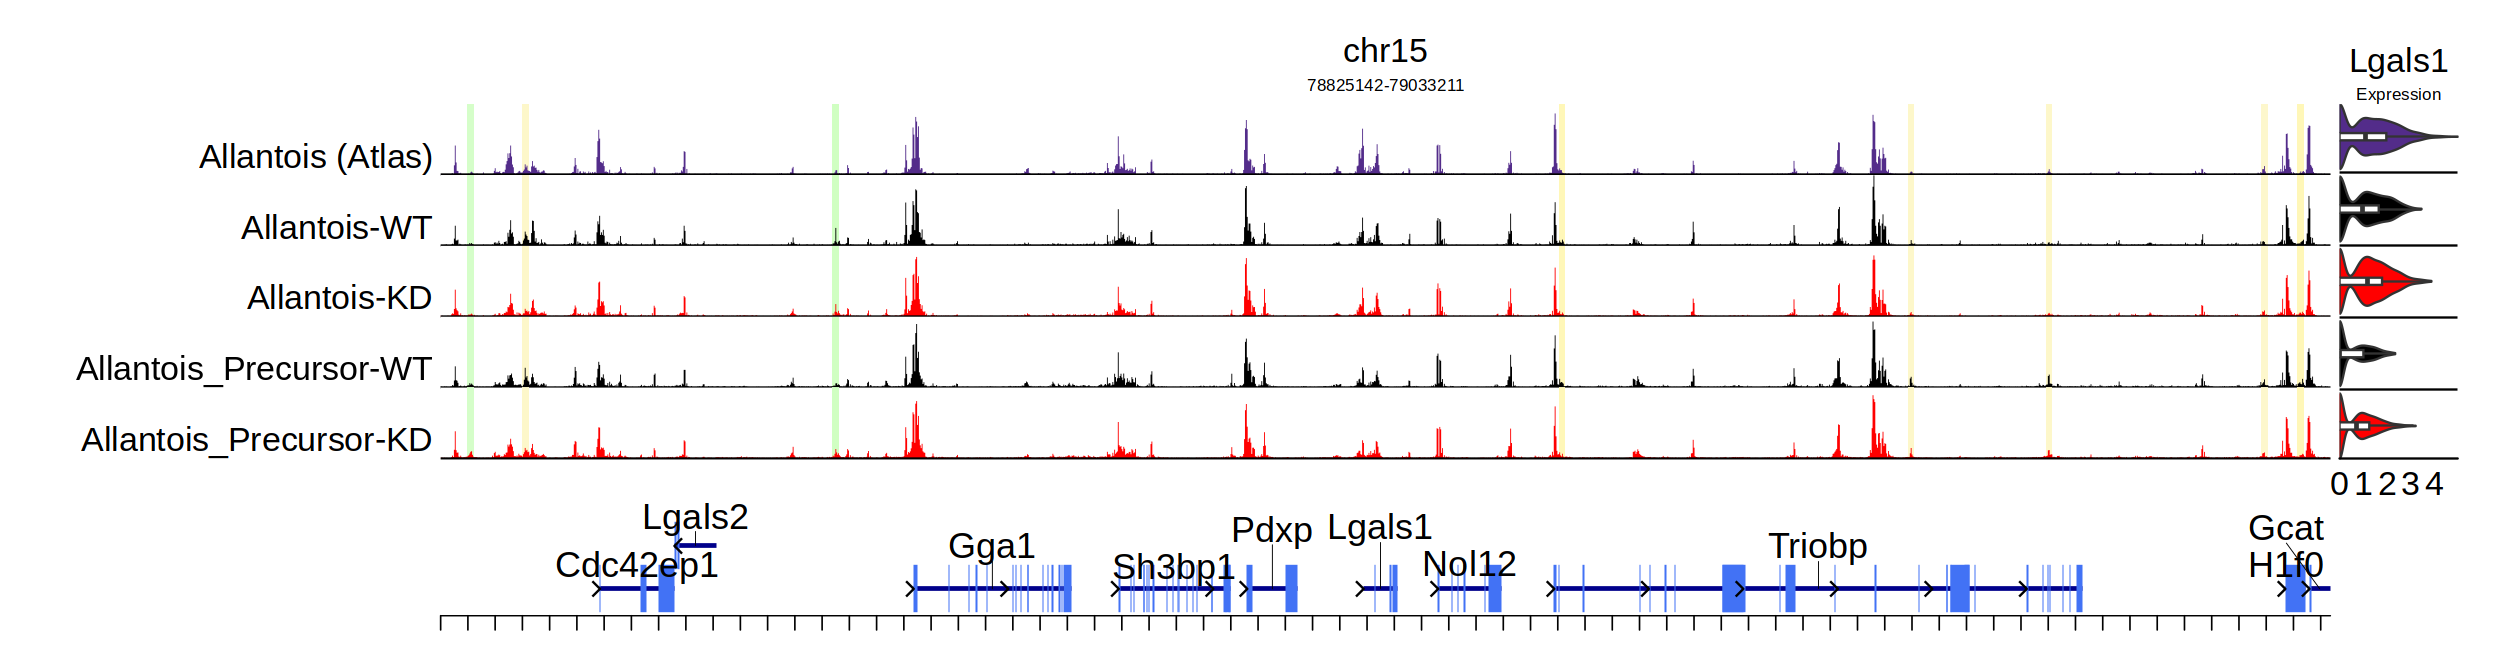

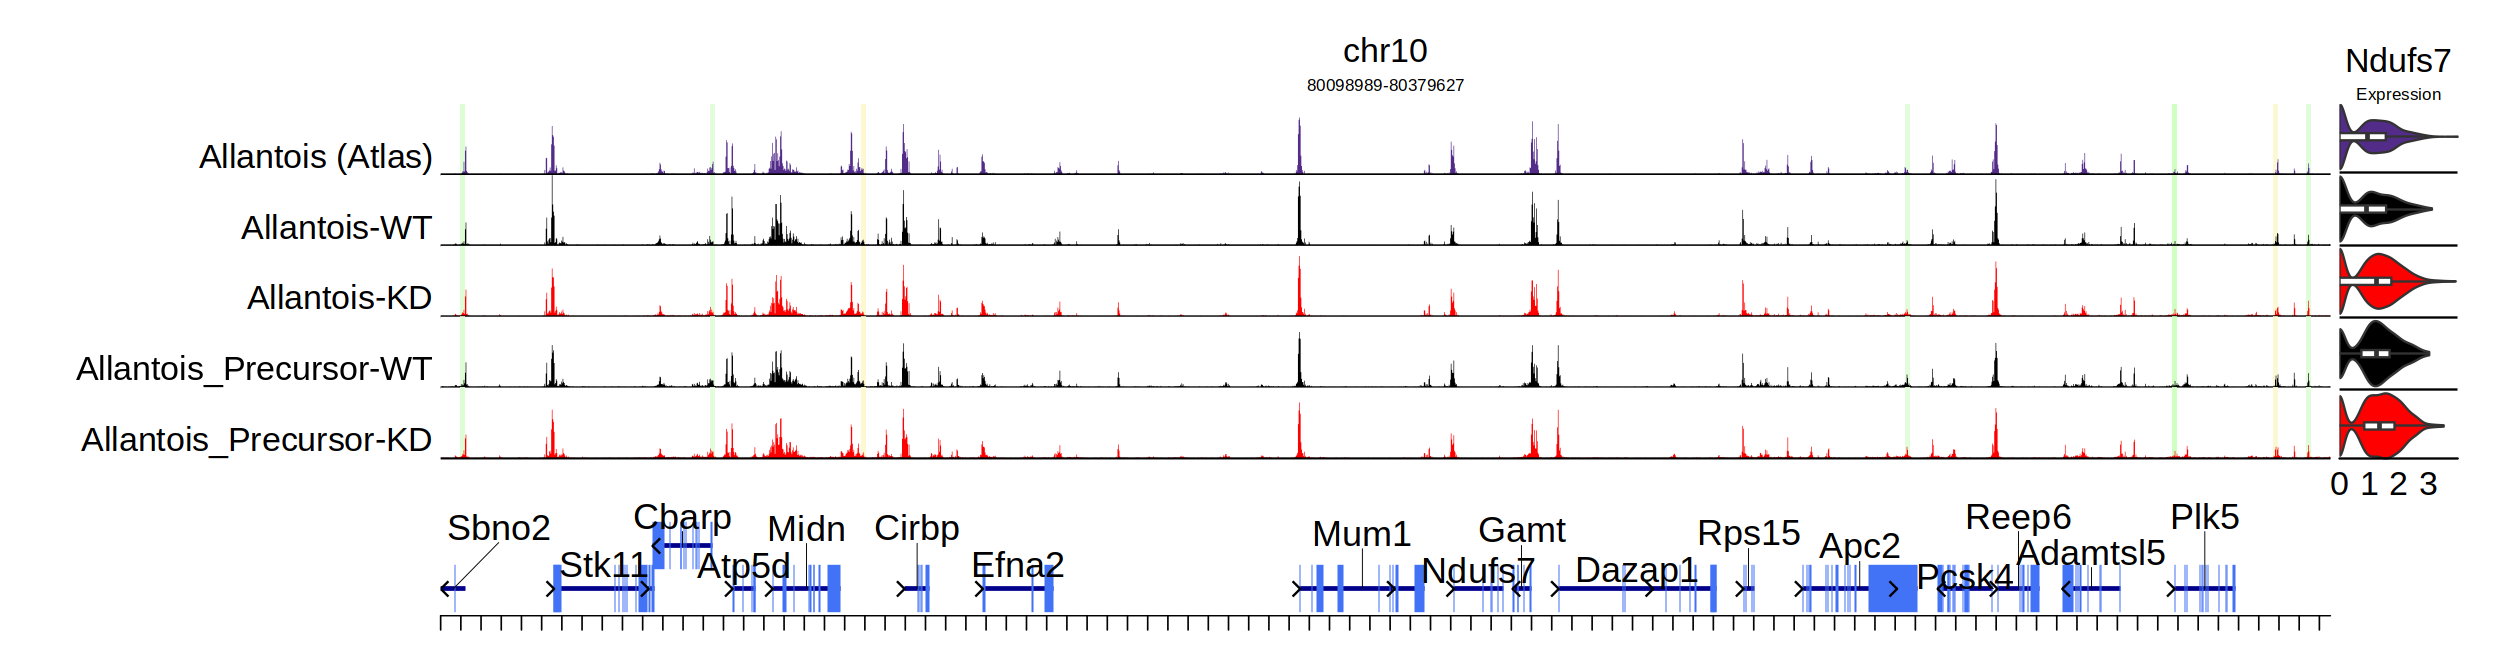

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]

[[11]]

[[12]]

[[13]]

[[14]]

[[15]]


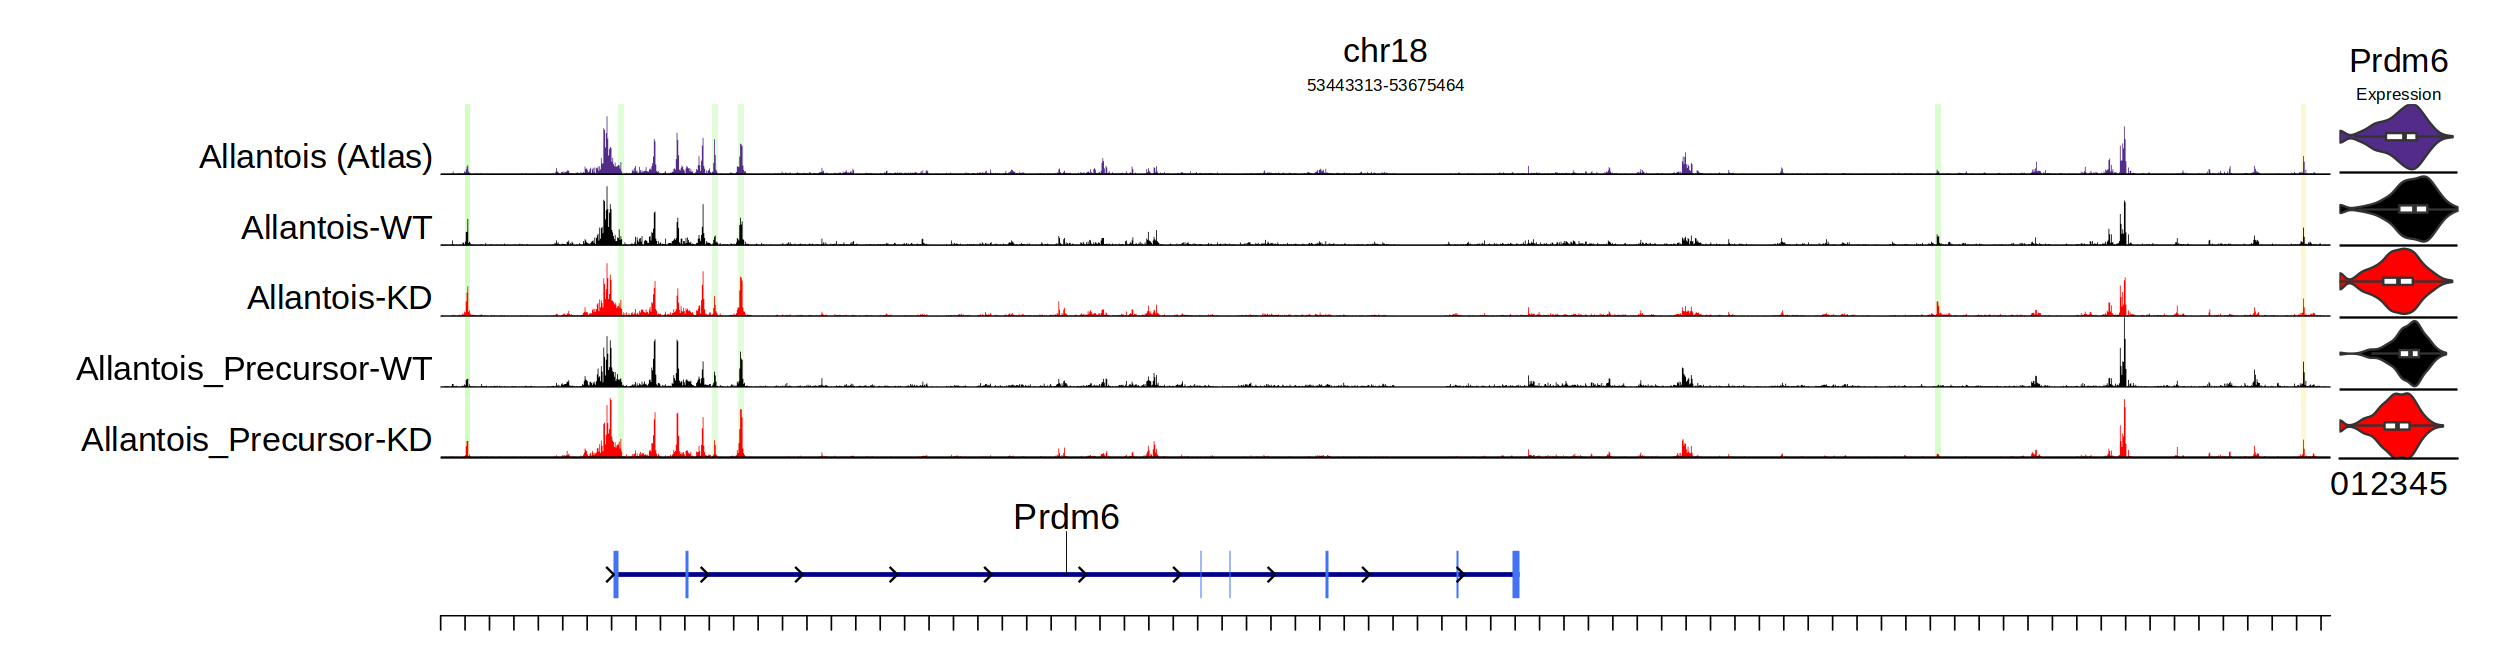

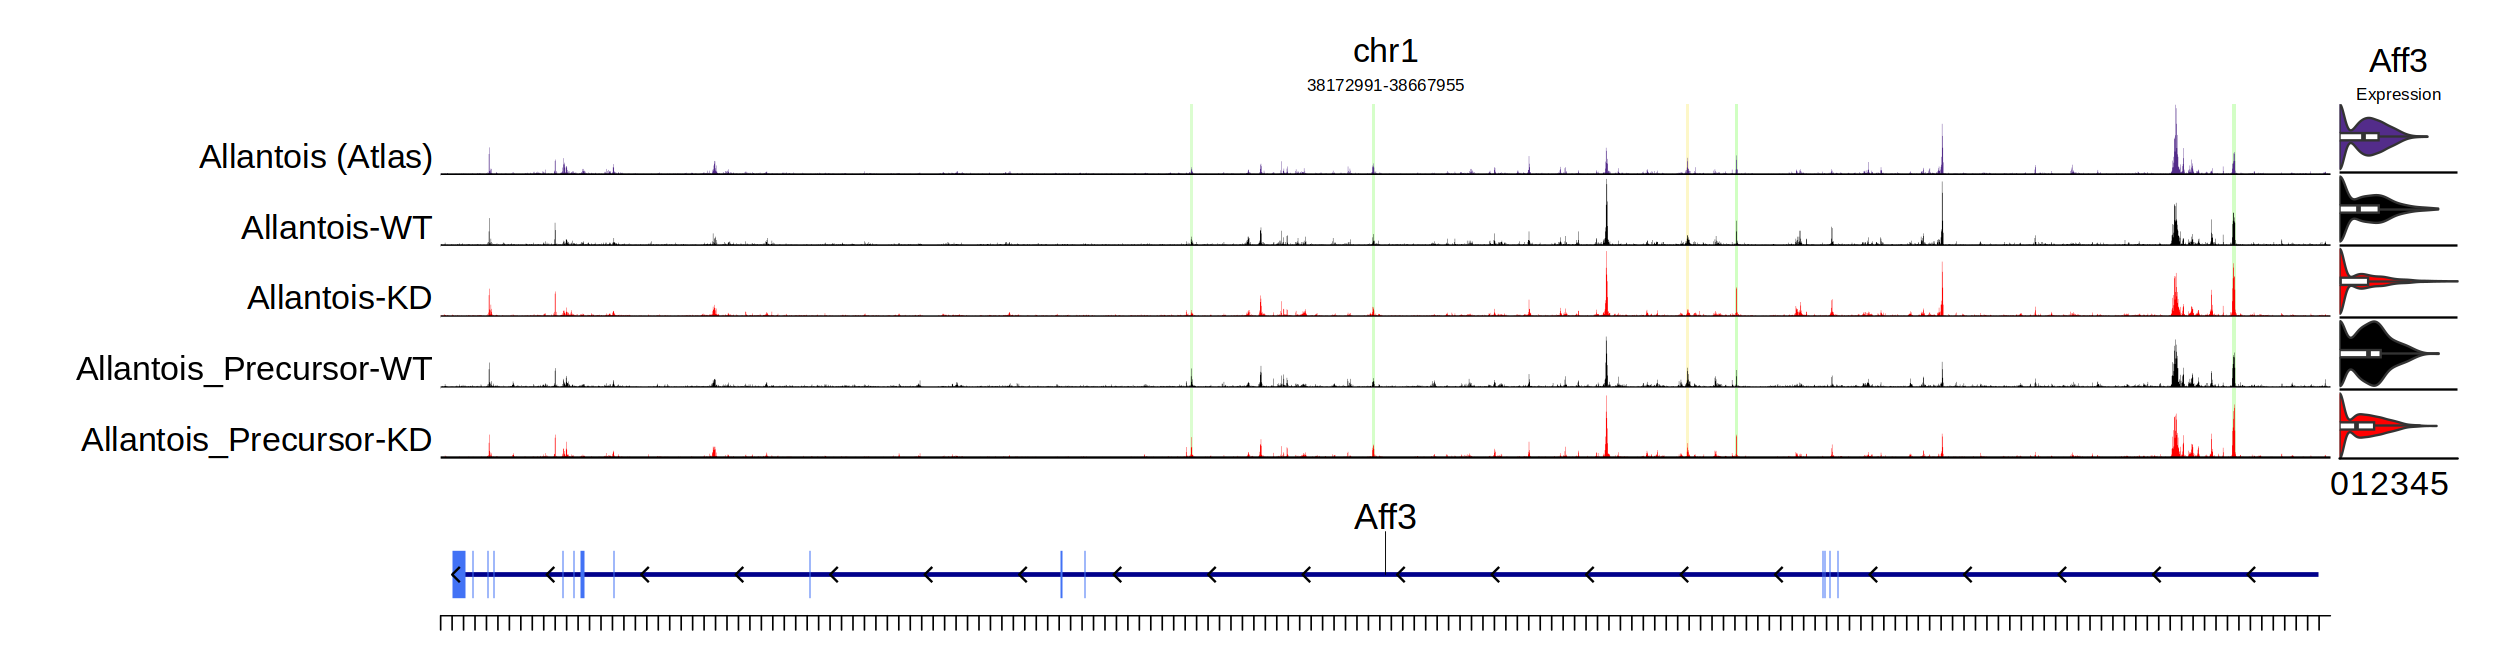

In [34]:
tmp = DEG_DAR[celltype %in% args$celltypes] %>% 
    .[,N := .N, by = 'gene'] %>% 
    .[order(-N)] %>% unique(by = 'gene') 

options(repr.plot.width=21, repr.plot.height=5.5)
mclapply(head(tmp$gene, 15), plot_region, mc.cores = 21)

In [56]:
head(DARs[order(logFC)])

peak,logFC,padj_fdr,mean_groupA,mean_groupB,cdr_groupA,cdr_groupB,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr2:10575852-10576452,-2.436,1.31e-23,3.64,1.66,0.17,0.07,Endothelium
chr16:20169634-20170234,-2.144,6.16e-21,3.65,1.88,0.15,0.08,Endothelium
chr5:93239761-93240361,-1.970,3.86e-23,4.05,2.33,0.18,0.12,Endothelium
chr2:118066275-118066875,-1.925,3.01e-19,3.79,2.14,0.17,0.09,Endothelium
chr17:24196988-24197588,-1.881,2.94e-28,4.50,2.79,0.27,0.17,Endothelium
chr2:157536629-157537229,-1.870,6.45e-20,3.93,2.28,0.20,0.13,Endothelium


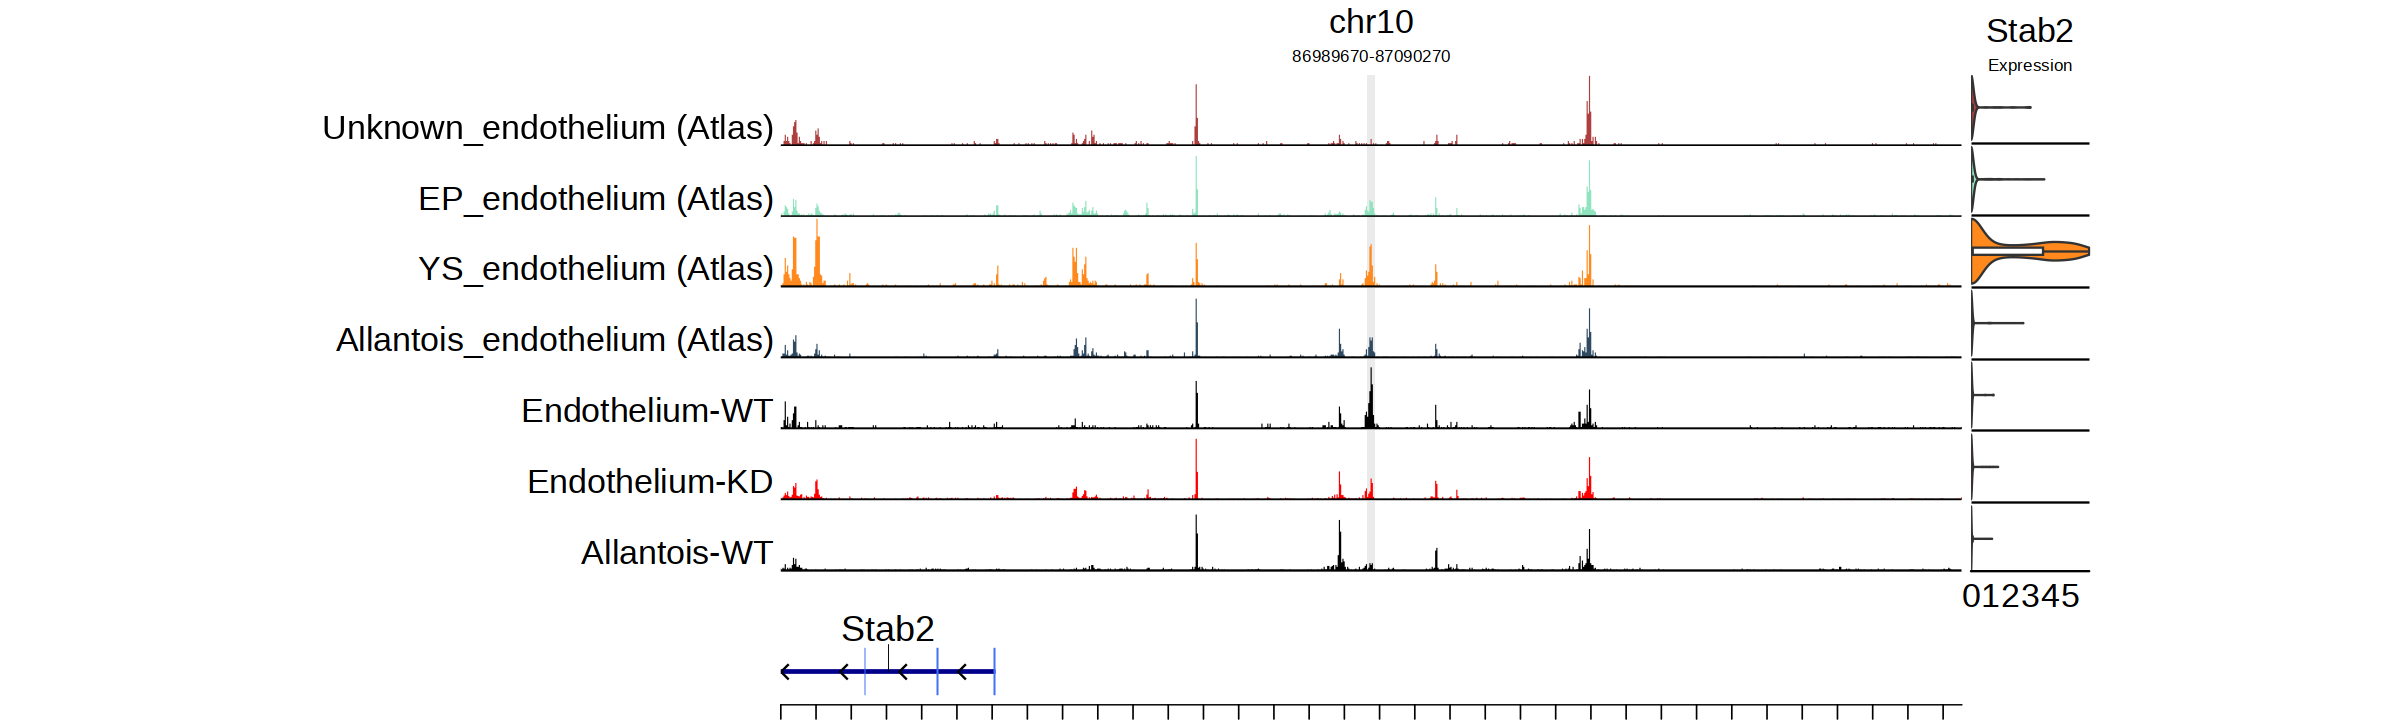

In [64]:
input_gene = 'Plat'
region = 'chr8:13699227-13699827'
region = DARs[order(logFC)][8, peak]
    options(repr.plot.height=6, repr.plot.width=20)
    plot_browser_track(gene = 'Stab2', # Only choose one of gene/input_region, otherwise will use region
                                  input_region = region, 
                                  bigwigs = WT_plot, 
                                  extend.upstream = 5e4,
                                  extend.downstream = 5e4, 
                                  highlight_regions = region,
                                  downsample.rate = 1, 
                                  no_label = F, 
                                  plot_expression = T,
                                  background_color = 'white',
                                  highlight_color = 'grey92',
                                  bw_height = 1.5, 
                                  gene_height = 2,
                                  bw_width = 25)

In [4]:
tmp = DARs[,diff:=cdr_groupB - cdr_groupA]

ERROR: Error in eval(expr, envir, enclos): object 'DARs' not found


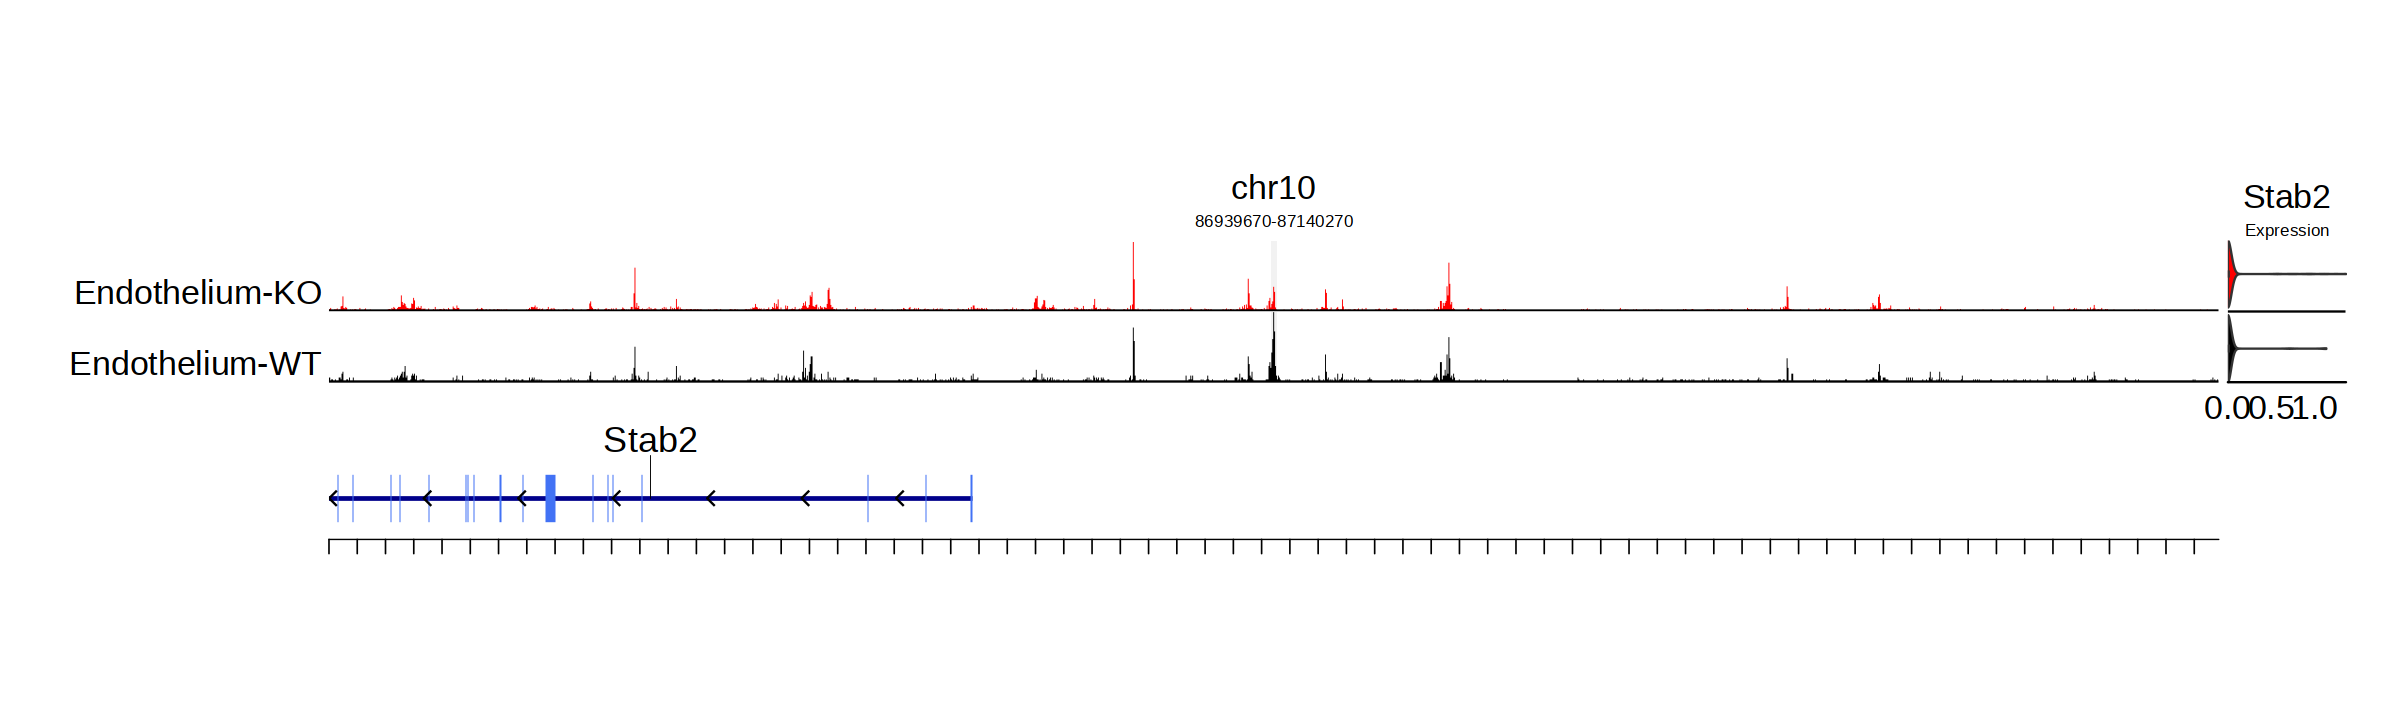

In [140]:
peak = DARs[order(-logFC)][3, peak]
peak = tmp[order(diff)][2,peak]
options(repr.plot.height=6, repr.plot.width=20)
    plot_browser_track(gene = 'Stab2', # Only choose one of gene/input_region, otherwise will use region
                                  input_region = peak, 
                                  bigwigs = WT_plot, 
                                  extend.upstream = 1e5,
                                  extend.downstream = 1e5, 
                                  highlight_regions = peak,
                                  downsample.rate = 1, 
                                  no_label = F, 
                                  plot_expression = T,
                                  background_color = 'white',
                                  highlight_color = 'grey95',
                                  bw_height = 1.5, 
                                  gene_height = 2.5,
                                  bw_width = 40)

#### Motif enrichment

In [35]:
plot_enr_heatmap = function(motif_enrichment, ntop=25, TFs = NULL, title = 'Motifs in marker peaks', subtitle = NULL, color = 'darkblue') {

    if(!is.null(TFs)){
        keep_tfs = TFs
    }else{
        keep_tfs = motif_enrichment %>% .[,variable:=factor(celltype, levels= names(opts$celltype_v2.colors))] %>% .[order(c(celltype, -mlog10Padj))] %>% .[, head(.SD, ntop),  by=celltype] %>% .$feature   
    }
    
    enriched.dt = motif_enrichment[feature %in% keep_tfs] %>% .[order( -mlog10Padj)] %>% 
        #.[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
         .[,feature:=factor(feature, levels=unique(keep_tfs))] %>%
        .[,variable:=factor(celltype, levels=names(opts$celltype_v2.colors))]
    
    p = ggplot(enriched.dt, aes(feature, celltype, color = Enrichment, size=mlog10Padj)) + 
        geom_point() +
        scale_color_gradient(low='white', high=color, name='-log10(P-adj)') + # , breaks = c(0,100), labels = c('Min', 'Max')
        scale_y_discrete(expand = c(0, 0.5)) + 
        scale_x_discrete(expand = c(0, 0.5)) + 
        geom_hline(yintercept=seq(.5, 20, 1), alpha=0.2) + 
        geom_hline(yintercept=c(6.5, 7.5), alpha=1) + 
        labs(title = title, caption = subtitle) + 
        theme(text=element_text(size=20), 
             axis.text = element_text(color='black'),
             axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=23), 
             axis.text.y= element_text(hjust=1, size = 20), # element_blank(), #
             axis.title = element_blank(),
             panel.border = element_rect(color='black', linewidth=1.5, fill = NA),
             panel.background = element_blank(),
             plot.title = element_text(size=25, face='plain', hjust=0.5),
             axis.line = element_blank(),
             legend.title = element_text(hjust=0, vjust = 1),
             legend.text = element_text(hjust=0.5, vjust = 0.5),
             legend.position = 'bottom')
    
p
    return(p)
}

In [36]:
# matches <- getMatches(ArchRProject, 'Motif_cisbp')
# rownames(matches) = rownames(atac.sce)

io$multiome = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/'
silico_chip = readRDS(file.path(io$multiome, 'vitro_peaks_silicoChIP_cisbp.rds'))
# jaspar_silico_chip = readRDS(file.path(io$multiome, 'vitro_peaks_silicoChIP_jaspar2020.rds'))
assay(silico_chip, 'matches') = assay(silico_chip, 'VirtualChipScores') > 0.20
assay(silico_chip, 'motifScores') = NULL
assay(silico_chip, 'motifMatches') = NULL
assay(silico_chip, 'motifCounts') = NULL
assay(silico_chip, 'VirtualChipScores') = NULL
matches = silico_chip

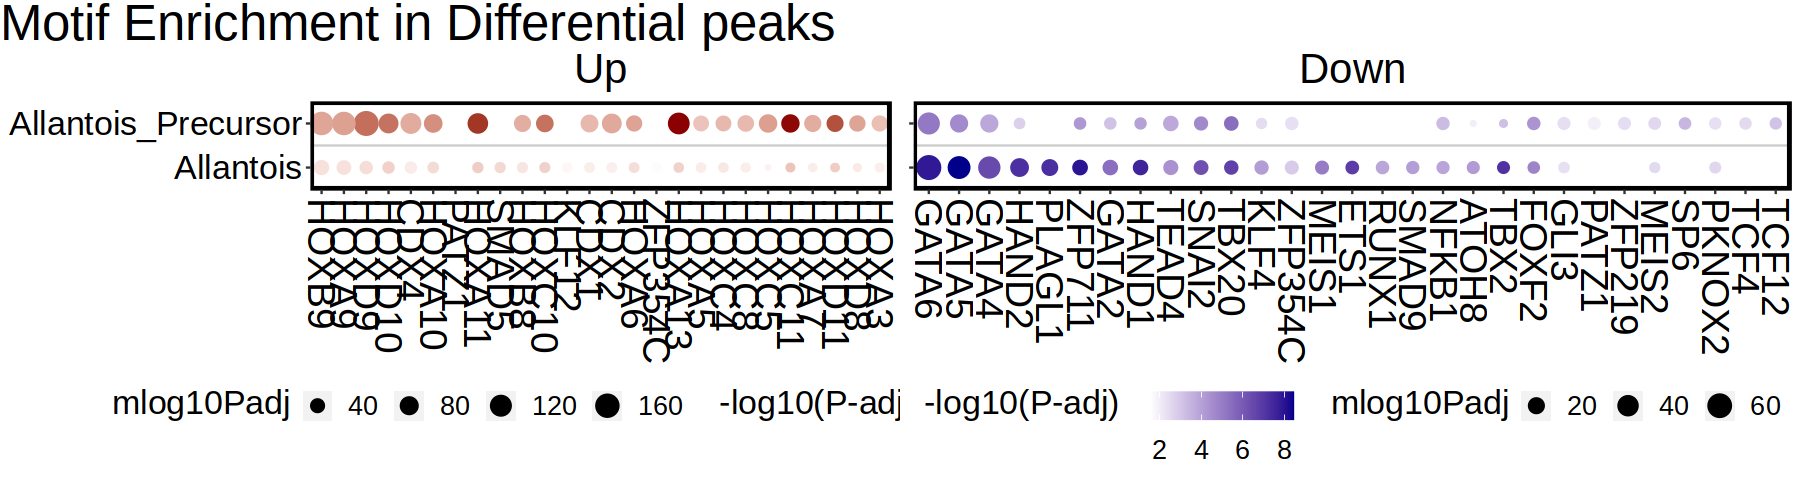

In [39]:
ntop = 20
options(repr.plot.width=10, repr.plot.height=4)

up = lapply(args$celltypes, function(x){
    tmp = as.data.table(ArchR:::.computeEnrichment(matches, DARs[celltype == x & logFC > 0.5 & padj_fdr < 5e-2, peak], seq_len(nrow(matches)))) %>%
            .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
            .[mlog10Padj > -log10(0.05)] %>% 
            .[,celltype := x]
    return(tmp)
}) %>% rbindlist() %>% 
    .[, celltype := factor(celltype, levels = names(opts$celltype_v2.colors))]
p1 = plot_enr_heatmap(up, ntop = ntop, title = 'Up', color = 'darkred')

down = lapply(args$celltypes, function(x){
    tmp = as.data.table(ArchR:::.computeEnrichment(matches, DARs[celltype == x & logFC <= -0.5 & padj_fdr < 5e-2, peak], seq_len(nrow(matches)))) %>%
            .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
            .[mlog10Padj > -log10(0.05)] %>% 
            .[,celltype := x]
    return(tmp)
}) %>% rbindlist() %>% 
    .[, celltype := factor(celltype, levels = names(opts$celltype_v2.colors))]
p2 = plot_enr_heatmap(down, ntop = ntop, title = 'Down')

options(repr.plot.width=15, repr.plot.height=4)

ggarrange(p1, p2 + theme(axis.text.y = element_blank()), align = 'h', widths = c(1, 1), nrow = 1) + 
    ggtitle('Motif Enrichment in Differential peaks') + 
    theme(plot.title = element_text(size = 30, hjust = 0),
            plot.title.position = "plot",
            plot.margin = unit(c(0,0, 0, 0), 'lines'))

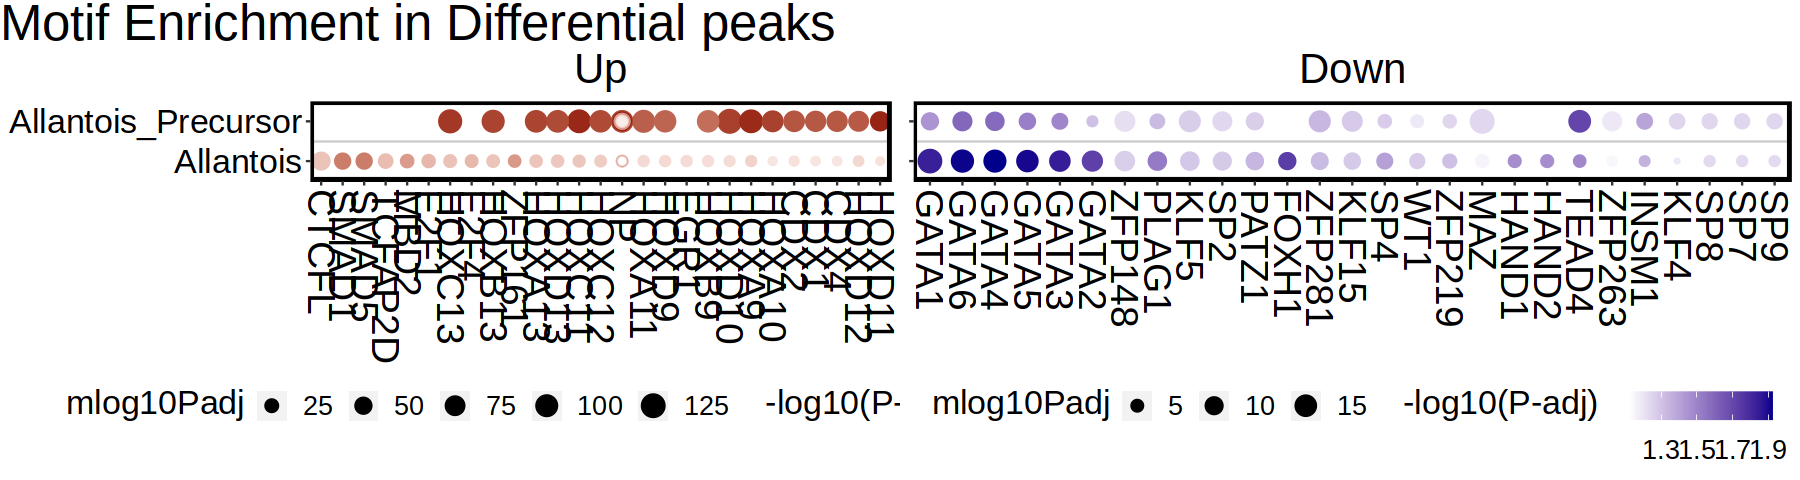

In [38]:
motifs = getMatches(ArchRProject, 'Motif_cisbp')
colnames(motifs) = str_to_upper(str_split(colnames(motifs), '_') %>% map_chr(1))
rownames(motifs) = rownames(silico_chip)

ntop = 20
options(repr.plot.width=8, repr.plot.height=4)

up = lapply(args$celltypes, function(x){
    tmp = as.data.table(ArchR:::.computeEnrichment(motifs, DARs[celltype == x & logFC > 0.5 & padj_fdr < 5e-2, peak], seq_len(nrow(matches)))) %>%
            .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
            .[mlog10Padj > -log10(0.05)] %>% 
            .[,celltype := x]
    return(tmp)
}) %>% rbindlist() %>% 
    .[, celltype := factor(celltype, levels = names(opts$celltype_v2.colors))]
p1 = plot_enr_heatmap(up, ntop = ntop, title = 'Up', color = 'darkred')

down = lapply(args$celltypes, function(x){
    tmp = as.data.table(ArchR:::.computeEnrichment(motifs, DARs[celltype == x & logFC <= -0.5 & padj_fdr < 5e-2, peak], seq_len(nrow(matches)))) %>%
            .[,feature := str_split(feature, '_') %>% map_chr(1)] %>% 
            .[mlog10Padj > -log10(0.05)] %>% 
            .[,celltype := x]
    return(tmp)
}) %>% rbindlist() %>% 
    .[, celltype := factor(celltype, levels = names(opts$celltype_v2.colors))]
p2 = plot_enr_heatmap(down, ntop = ntop, title = 'Down')

options(repr.plot.width=15, repr.plot.height=4)

ggarrange(p1, p2 + theme(axis.text.y = element_blank()), align = 'h', widths = c(1, 1), nrow = 1) + 
    ggtitle('Motif Enrichment in Differential peaks') + 
    theme(plot.title = element_text(size = 30, hjust = 0),
            plot.title.position = "plot",
            plot.margin = unit(c(0,0, 0, 0), 'lines'))